# Viken KHATCHERIAN projet 10 Openclassrooms 

# Étape 4 — Apprentissage supervisé et semi-supervisé

## Objectif

L'objectif de cette étape est d'évaluer l'apport des données faiblement labellisées
dans une tâche de classification binaire `cancer` / `normal`.

Deux stratégies seront comparées :

1. **Apprentissage supervisé** :
   entraînement du CNN uniquement sur les images fortement labellisées du jeu
   d'entraînement.

2. **Apprentissage semi-supervisé** :
   pré-entraînement du même CNN sur les images faiblement labellisées,
   puis poursuite de l'entraînement sur les images fortement labellisées.

Dans les deux cas, l'évaluation finale sera réalisée sur un jeu de test fortement
labellisé, équilibré et strictement séparé des données utilisées pour l'entraînement.

Les principales métriques retenues seront l'accuracy, la précision, le rappel
(sensibilité), le F1-score et la matrice de confusion.

> Contexte : ce projet constitue une étude exploratoire de faisabilité en
> Computer Vision appliquée à l'imagerie cérébrale. Les résultats ne constituent
> pas une validation clinique d'un système de diagnostic.

In [1]:
# Imports et configuration

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

# Reproductibilité


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Chemins du projet

PROJECT_ROOT = Path("/mnt/projects/vk_oc_projet10_brainscanai")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

EMBEDDINGS_PATH = PROCESSED_DIR / "embeddings_resnet50.csv"

# Configuration du calcul


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Projet : {PROJECT_ROOT}")
print(f"Device : {DEVICE}")

Projet : /mnt/projects/vk_oc_projet10_brainscanai
Device : cuda


In [2]:
# Chargement des embeddings produits dans le Notebook 1

if not EMBEDDINGS_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {EMBEDDINGS_PATH}"
    )

embeddings_df = pd.read_csv(EMBEDDINGS_PATH)

print("Dimensions :", embeddings_df.shape)
print("\nColonnes métadonnées :")
print(embeddings_df[["label", "subset", "filename", "path", "md5"]].head())

Dimensions : (1410, 2053)

Colonnes métadonnées :
    label   subset                                  filename  \
0  cancer  labeled  05340cd4-3bb2-459d-9937-bf27d52d8351.jpg   
1  cancer  labeled  0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg   
2  cancer  labeled  0f718241-8f63-4b55-81ce-315324b51069.jpg   
3  cancer  labeled  11a7a426-4806-401e-98b2-b96e7094d1a6.jpg   
4  cancer  labeled  1c043dbb-4623-4769-8e5e-0223bd745040.jpg   

                                                path  \
0  /mnt/projects/vk_oc_projet10_brainscanai/data/...   
1  /mnt/projects/vk_oc_projet10_brainscanai/data/...   
2  /mnt/projects/vk_oc_projet10_brainscanai/data/...   
3  /mnt/projects/vk_oc_projet10_brainscanai/data/...   
4  /mnt/projects/vk_oc_projet10_brainscanai/data/...   

                                md5  
0  82feb195cc989de29f0d584705afd746  
1  1fe2130e1834ff8646f635f6a6f86dc1  
2  32debb468cdfa4c513e648c61f8349f8  
3  bf80e340a7b4fcf553202847221bfe1f  
4  d642b0a782a25dee640a9b76a2f55112  


In [3]:
# Identification des jeux de données

# Images fortement labellisées
mask_strong = embeddings_df["subset"].eq("labeled")

strong_df = embeddings_df.loc[
    mask_strong,
    ["filename", "path", "md5", "label"]
].copy()

# Images faiblement labellisées
mask_weak = embeddings_df["subset"].eq("unlabeled")

weak_df = embeddings_df.loc[
    mask_weak,
    ["filename", "path", "md5"]
].copy()

print(f"Images fortement labellisées : {len(strong_df)}")
print(f"Images faiblement labellisées : {len(weak_df)}")

Images fortement labellisées : 99
Images faiblement labellisées : 1311


In [4]:
# Vérification des labels forts


print("Répartition des labels forts :")
print(strong_df["label"].value_counts())

print("\nNombre total :", len(strong_df))

Répartition des labels forts :
label
cancer    50
normal    49
Name: count, dtype: int64

Nombre total : 99


In [5]:
# Split fortement labellisé : train / test

strong_indices = strong_df.index.to_numpy()
strong_labels = strong_df["label"].to_numpy()

strong_train_indices, strong_test_indices = train_test_split(
    strong_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=strong_labels
)

strong_train_df = strong_df.loc[strong_train_indices].copy()
strong_test_df = strong_df.loc[strong_test_indices].copy()

print("Strong train :", len(strong_train_df))
print("Strong test  :", len(strong_test_df))

print("\nRépartition train :")
print(strong_train_df["label"].value_counts())

print("\nRépartition test :")
print(strong_test_df["label"].value_counts())

Strong train : 79
Strong test  : 20

Répartition train :
label
cancer    40
normal    39
Name: count, dtype: int64

Répartition test :
label
normal    10
cancer    10
Name: count, dtype: int64


In [6]:
# Contrôle de fuite de données

train_paths = set(strong_train_df["path"])
test_paths = set(strong_test_df["path"])
weak_paths = set(weak_df["path"])

print("Intersection train / test :", len(train_paths & test_paths))
print("Intersection weak / train :", len(weak_paths & train_paths))
print("Intersection weak / test  :", len(weak_paths & test_paths))

assert len(train_paths & test_paths) == 0
assert len(weak_paths & train_paths) == 0
assert len(weak_paths & test_paths) == 0

print("\n Aucun chevauchement détecté.")

Intersection train / test : 0
Intersection weak / train : 0
Intersection weak / test  : 0

 Aucun chevauchement détecté.


## Génération des labels faibles définitifs

Les labels faibles utilisés pour l'apprentissage semi-supervisé sont générés
à partir des représentations visuelles extraites par ResNet-50 dans le
Notebook 1.

Afin de préserver l'indépendance du jeu de test, le pipeline de
standardisation, de réduction dimensionnelle et de clustering est ajusté
uniquement sur les données destinées à l'apprentissage :

- 79 images fortement labellisées du jeu d'entraînement ;
- 1 311 images initialement non labellisées.

Les 20 images fortement labellisées du jeu de test sont totalement exclues
de cette procédure.

Les labels forts des 79 images d'entraînement sont utilisés uniquement après
le clustering afin d'associer les identifiants arbitraires des clusters aux
classes `cancer` et `normal`.

In [7]:
# Extraction des embeddings pour le pipeline train-safe


# Les embeddings sont les 2048 colonnes générées dans le Notebook 1.
embedding_columns = [
    column for column in embeddings_df.columns
    if column.startswith("feature_")
]

print(f"Nombre de features : {len(embedding_columns)}")

# Embeddings des données fortement labellisées train
X_strong_train = embeddings_df.loc[
    strong_train_df.index,
    embedding_columns
].to_numpy(dtype=np.float32)

# Embeddings des données faiblement labellisées
X_weak = embeddings_df.loc[
    weak_df.index,
    embedding_columns
].to_numpy(dtype=np.float32)

# Embeddings du jeu de test
X_strong_test = embeddings_df.loc[
    strong_test_df.index,
    embedding_columns
].to_numpy(dtype=np.float32)

print(f"Strong train : {X_strong_train.shape}")
print(f"Weak         : {X_weak.shape}")
print(f"Strong test  : {X_strong_test.shape}")

Nombre de features : 2048
Strong train : (79, 2048)
Weak         : (1311, 2048)
Strong test  : (20, 2048)


In [8]:
# Ensemble utilisé pour le clustering


X_clustering = np.vstack([
    X_strong_train,
    X_weak
])

print("Dimensions de l'ensemble de clustering :", X_clustering.shape)

assert X_clustering.shape == (1390, 2048)

print(" Les 20 images du jeu de test ne sont pas incluses.")

Dimensions de l'ensemble de clustering : (1390, 2048)
 Les 20 images du jeu de test ne sont pas incluses.


In [9]:
# Standardisation train-safe


from sklearn.preprocessing import StandardScaler

scaler_step4 = StandardScaler()

X_clustering_scaled = scaler_step4.fit_transform(
    X_clustering
).astype(np.float32)

print("Avant standardisation :", X_clustering.shape)
print("Après standardisation :", X_clustering_scaled.shape)

print(
    "NaN :",
    np.isnan(X_clustering_scaled).sum(),
    "| Inf :",
    np.isinf(X_clustering_scaled).sum()
)

assert X_clustering_scaled.shape == (1390, 2048)
assert np.isnan(X_clustering_scaled).sum() == 0
assert np.isinf(X_clustering_scaled).sum() == 0

print(" Standardisation validée.")

Avant standardisation : (1390, 2048)
Après standardisation : (1390, 2048)
NaN : 0 | Inf : 0
 Standardisation validée.


In [10]:
# Réduction dimensionnelle PCA

from sklearn.decomposition import PCA

N_COMPONENTS_PCA = 688

pca_step4 = PCA(
    n_components=N_COMPONENTS_PCA,
    random_state=SEED
)

X_clustering_pca = pca_step4.fit_transform(
    X_clustering_scaled
).astype(np.float32)

print("Avant PCA :", X_clustering_scaled.shape)
print("Après PCA :", X_clustering_pca.shape)

print(
    f"Variance expliquée cumulée : "
    f"{pca_step4.explained_variance_ratio_.sum():.4f}"
)

assert X_clustering_pca.shape == (1390, 688)
assert np.isnan(X_clustering_pca).sum() == 0
assert np.isinf(X_clustering_pca).sum() == 0

print(" PCA validée.")

Avant PCA : (1390, 2048)
Après PCA : (1390, 688)
Variance expliquée cumulée : 0.9502
 PCA validée.


In [11]:
# K-Means train-safe avec deux clusters

from sklearn.cluster import KMeans

kmeans_step4 = KMeans(
    n_clusters=2,
    random_state=SEED,
    n_init=20,
    max_iter=300
)

clusters_step4 = kmeans_step4.fit_predict(
    X_clustering_pca
)

print("Nombre d'images clusterisées :", len(clusters_step4))
print("Nombre de clusters :", len(np.unique(clusters_step4)))

print("\nRépartition des clusters :")
print(pd.Series(clusters_step4).value_counts().sort_index())

assert len(clusters_step4) == 1390
assert set(np.unique(clusters_step4)) == {0, 1}

print("\n K-Means train-safe terminé.")

Nombre d'images clusterisées : 1390
Nombre de clusters : 2

Répartition des clusters :
0    499
1    891
Name: count, dtype: int64

 K-Means train-safe terminé.


In [12]:
# Correspondance cluster > classe

# Les 79 premières lignes correspondent aux strong_train
clusters_strong_train = clusters_step4[:len(strong_train_df)]

y_strong_train = strong_train_df["label"].to_numpy()

cluster_label_table = pd.crosstab(
    clusters_strong_train,
    y_strong_train
)

print("Correspondance entre clusters et labels forts :")
display(cluster_label_table)

Correspondance entre clusters et labels forts :


col_0,cancer,normal
row_0,,
0,18,1
1,22,38


### Interprétation de la répartition des classes dans les clusters

Pour le **cluster 0** :

> **18 images sur 19 sont `cancer`**, soit environ **94,7 %** de cancer parmi les labels forts.

Pour le **cluster 1** :

> **38 images sur 60 sont `normal`**, soit environ **63,3 %** de normal parmi les labels forts.

Le **cluster 0 est donc relativement homogène**, tandis que le **cluster 1 est beaucoup plus mélangé**.

Cela confirme également ce qui a été observé dans le notebook 1 avec l'**ARI de l'étape 3** : le clustering possède une **information partiellement pertinente** pour distinguer les classes `cancer` et `normal`, mais il est loin d'être parfait.

Il est donc important de ne pas écrire :

> « K-Means détecte les cancers. »

Mais de considérer plutôt que :

> **« Les clusters sont associés aux classes `cancer` et `normal` selon la classe majoritaire observée sur les données fortement labellisées d'entraînement. Cette correspondance permet de générer des labels faibles pour les données non labellisées, mais leur fiabilité reste limitée, notamment pour le cluster 1. »**

Cette distinction est essentielle : les labels générés par K-Means sont des **pseudo-labels**, et non des diagnostics médicaux.

## Génération des labels faibles

Les identifiants de clusters étant arbitraires, ils sont convertis en classes
`cancer` / `normal` à partir de la classe majoritaire observée sur les
79 images fortement labellisées du jeu d'entraînement.

Cette correspondance est ensuite appliquée aux 1 311 images initialement
non labellisées.

Les labels obtenus sont considérés comme des **labels faibles** et ne sont
pas assimilés à des annotations humaines.

In [13]:
# Génération des labels faibles


# Correspondance obtenue à partir de la classe majoritaire
# observée sur les 79 images fortement labellisées du train.
cluster_to_label = {
    0: "cancer",
    1: "normal"
}

# Les 1311 dernières lignes de clusters_step4 correspondent
# aux images initialement non labellisées.
weak_clusters = clusters_step4[len(strong_train_df):]

assert len(weak_clusters) == len(weak_df)

# Création du jeu faiblement labellisé
weak_labels_df = weak_df.copy()

weak_labels_df["cluster"] = weak_clusters
weak_labels_df["weak_label"] = (
    weak_labels_df["cluster"]
    .map(cluster_to_label)
)

print("Nombre d'images faiblement labellisées :", len(weak_labels_df))

print("\nRépartition des clusters :")
print(
    weak_labels_df["cluster"]
    .value_counts()
    .sort_index()
)

print("\nRépartition des weak labels :")
print(
    weak_labels_df["weak_label"]
    .value_counts()
)

print("\nNombre de labels faibles manquants :")
print(
    weak_labels_df["weak_label"].isna().sum()
)

Nombre d'images faiblement labellisées : 1311

Répartition des clusters :
cluster
0    480
1    831
Name: count, dtype: int64

Répartition des weak labels :
weak_label
normal    831
cancer    480
Name: count, dtype: int64

Nombre de labels faibles manquants :
0


### Répartition des labels faibles

La répartition est donc :

- `cancer` : **480 / 1 311 = 36,6 %**
- `normal` : **831 / 1 311 = 63,4 %**

Cela correspond à la structure des clusters obtenue par le **K-Means train-safe**.

### Un point important pour notre analyse

Nous avons maintenant :

```text
79 strong train
40 cancer / 39 normal
        │
        ├── K-Means
        │
        ↓
1 311 weak
480 cancer / 831 normal

20 strong test
10 cancer / 10 normal
        │
        ↓
évaluation finale uniquement

Le jeu faiblement labellisé est donc déséquilibré, contrairement au jeu de test qui reste parfaitement équilibré.

## Contrôle qualité des labels faibles

Les labels générés par clustering constituent des pseudo-labels et ne doivent
pas être considérés comme des annotations humaines.

Afin d'estimer leur cohérence, nous comparons sur les 79 images fortement
labellisées du jeu d'entraînement :

- les labels humains ;
- les classes déduites des clusters.

Cette analyse permet d'identifier les limites du pseudo-étiquetage avant son
utilisation pour l'apprentissage du CNN.

In [14]:
# Contrôle qualité des labels faibles


# Conversion des clusters du strong train en pseudo-labels
strong_train_weak_labels = pd.Series(
    clusters_strong_train
).map(cluster_to_label).to_numpy()

# Labels humains de référence
strong_train_true_labels = strong_train_df["label"].to_numpy()

# Comparaison
comparison_df = pd.DataFrame({
    "true_label": strong_train_true_labels,
    "weak_label": strong_train_weak_labels
})

print("Matrice de comparaison :")
display(
    pd.crosstab(
        comparison_df["true_label"],
        comparison_df["weak_label"],
        margins=True
    )
)

Matrice de comparaison :


weak_label,cancer,normal,All
true_label,,,
cancer,18,22,40
normal,1,38,39
All,19,60,79


In [15]:
# Mesure de cohérence des pseudo-labels


from sklearn.metrics import accuracy_score, f1_score

weak_label_accuracy = accuracy_score(
    comparison_df["true_label"],
    comparison_df["weak_label"]
)

weak_label_f1 = f1_score(
    comparison_df["true_label"],
    comparison_df["weak_label"],
    pos_label="cancer"
)

print(f"Accuracy des pseudo-labels sur strong train : {weak_label_accuracy:.4f}")
print(f"F1-score des pseudo-labels sur strong train : {weak_label_f1:.4f}")

Accuracy des pseudo-labels sur strong train : 0.7089
F1-score des pseudo-labels sur strong train : 0.6102


## Qualité des pseudo-labels

Donc :

- **Accuracy des pseudo-labels : 0,7089 → 70,89 %**
- **F1-score `cancer` : 0,6102**

Le système de pseudo-labellisation est **imparfait mais exploitable pour une expérimentation semi-supervisée**.

L'asymétrie des résultats est à remarquer :

- parmi les **40 vrais `cancer`**, seulement **18 sont identifiés comme `cancer`** ;
- **22 cancers sont donc pseudo-étiquetés `normal`** ;
- parmi les **39 vrais `normal`**, **38 sont correctement pseudo-étiquetés `normal`**.

Le clustering est donc **beaucoup plus fiable pour identifier `normal` que `cancer`**.

**Point important dans le contexte de BrainScanAI :** les erreurs de type **faux négatif** (`cancer` → `normal`) sont particulièrement préoccupantes.

Cela constitue une excellente justification pour **ne pas considérer les 1 311 labels faibles comme des vérités de référence**.

> **Les labels faibles sont des pseudo-labels issus d'un clustering et présentent une qualité estimée à 70,89 % d'accuracy et 0,6102 de F1-score sur les 79 images fortement labellisées d'entraînement. Ils sont donc utilisés comme source d'information complémentaire et non comme annotations de référence.**

In [16]:
# 4.2.9 — Sauvegarde des manifests
# Objectif :
# Sauvegarder séparément les trois ensembles de données utilisés
# pour l'étape 4 :
#
#   1. weak_labels_manifest.csv   → 1 311 images faiblement labellisées
#   2. strong_train_manifest.csv  → 79 images fortement labellisées
#   3. strong_test_manifest.csv   → 20 images fortement labellisées
#
# Le jeu de test reste totalement séparé du train et des weak labels.

from pathlib import Path
import pandas as pd

# Création du répertoire de sauvegarde


MANIFEST_DIR = Path(PROCESSED_DIR)

MANIFEST_DIR.mkdir(parents=True, exist_ok=True)


# Vérification des variables attendues


required_variables = [
    "weak_labels_df",
    "strong_train_df",
    "strong_test_df"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "Variables manquantes : "
        + ", ".join(missing_variables)
    )


# Création des copies pour éviter toute modification accidentelle des DataFrames de travail


weak_manifest = weak_labels_df.copy()
strong_train_manifest = strong_train_df.copy()
strong_test_manifest = strong_test_df.copy()


# Vérification minimale des colonnes


required_weak_columns = {
    "filename",
    "path",
    "weak_label"
}

required_strong_columns = {
    "filename",
    "path",
    "label"
}

missing_weak = required_weak_columns - set(weak_manifest.columns)
missing_train = required_strong_columns - set(strong_train_manifest.columns)
missing_test = required_strong_columns - set(strong_test_manifest.columns)

if missing_weak:
    raise ValueError(
        f"Colonnes manquantes dans weak_labels_df : {missing_weak}"
    )

if missing_train:
    raise ValueError(
        f"Colonnes manquantes dans strong_train_df : {missing_train}"
    )

if missing_test:
    raise ValueError(
        f"Colonnes manquantes dans strong_test_df : {missing_test}"
    )


# Sauvegarde des trois manifests


WEAK_MANIFEST_PATH = MANIFEST_DIR / "weak_labels_manifest.csv"
STRONG_TRAIN_MANIFEST_PATH = MANIFEST_DIR / "strong_train_manifest.csv"
STRONG_TEST_MANIFEST_PATH = MANIFEST_DIR / "strong_test_manifest.csv"

weak_manifest.to_csv(
    WEAK_MANIFEST_PATH,
    index=False
)

strong_train_manifest.to_csv(
    STRONG_TRAIN_MANIFEST_PATH,
    index=False
)

strong_test_manifest.to_csv(
    STRONG_TEST_MANIFEST_PATH,
    index=False
)

# Contrôle des fichiers créés

print("=" * 70)
print("Sauvegarde des manifests — Étape 4")
print("=" * 70)

print()
print("Fichiers sauvegardés :")
print(f"Weak labels  : {WEAK_MANIFEST_PATH}")
print(f"Strong train : {STRONG_TRAIN_MANIFEST_PATH}")
print(f"Strong test  : {STRONG_TEST_MANIFEST_PATH}")

print()
print("Dimensions :")
print(f"- Weak labels  : {weak_manifest.shape}")
print(f"- Strong train : {strong_train_manifest.shape}")
print(f"- Strong test  : {strong_test_manifest.shape}")


# Vérification des répartitions


print()
print("Répartition des weak labels :")
print(weak_manifest["weak_label"].value_counts())

print()
print("Répartition du strong train :")
print(strong_train_manifest["label"].value_counts())

print()
print("Répartition du strong test :")
print(strong_test_manifest["label"].value_counts())


# Contrôle des chevauchements


weak_files = set(weak_manifest["filename"])
train_files = set(strong_train_manifest["filename"])
test_files = set(strong_test_manifest["filename"])

overlap_weak_train = weak_files & train_files
overlap_weak_test = weak_files & test_files
overlap_train_test = train_files & test_files

print()
print("Contrôle des chevauchements :")
print(f"- Weak / train : {len(overlap_weak_train)}")
print(f"- Weak / test  : {len(overlap_weak_test)}")
print(f"- Train / test : {len(overlap_train_test)}")

assert len(overlap_weak_train) == 0
assert len(overlap_weak_test) == 0
assert len(overlap_train_test) == 0


# Vérification finale


assert WEAK_MANIFEST_PATH.exists()
assert STRONG_TRAIN_MANIFEST_PATH.exists()
assert STRONG_TEST_MANIFEST_PATH.exists()

print()
print("Les trois manifests ont été sauvegardés.")
print("Les trois ensembles sont séparés.")
print("Aucun chevauchement détecté.")
print("Le jeu de test reste isolé.")

Sauvegarde des manifests — Étape 4

Fichiers sauvegardés :
Weak labels  : /mnt/projects/vk_oc_projet10_brainscanai/data/processed/weak_labels_manifest.csv
Strong train : /mnt/projects/vk_oc_projet10_brainscanai/data/processed/strong_train_manifest.csv
Strong test  : /mnt/projects/vk_oc_projet10_brainscanai/data/processed/strong_test_manifest.csv

Dimensions :
- Weak labels  : (1311, 5)
- Strong train : (79, 4)
- Strong test  : (20, 4)

Répartition des weak labels :
weak_label
normal    831
cancer    480
Name: count, dtype: int64

Répartition du strong train :
label
cancer    40
normal    39
Name: count, dtype: int64

Répartition du strong test :
label
normal    10
cancer    10
Name: count, dtype: int64

Contrôle des chevauchements :
- Weak / train : 0
- Weak / test  : 0
- Train / test : 0

Les trois manifests ont été sauvegardés.
Les trois ensembles sont séparés.
Aucun chevauchement détecté.
Le jeu de test reste isolé.


### Préparation des jeux de données PyTorch

Les trois ensembles sont chargés séparément à partir des manifests créés à l'étape précédente.

- Le jeu faiblement labellisé contient 1 311 images et leurs pseudo-labels.
- Le jeu fortement labellisé d'entraînement contient 79 images et leurs labels réels.
- Le jeu fortement labellisé de test contient 20 images et reste exclusivement réservé à l'évaluation finale.

Cette séparation est maintenue pendant toute la phase d'entraînement afin d'éviter toute fuite de données.

In [17]:
# Chargement et contrôle des manifests


from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# Chemins du projet et des manifests
# ------------------------------------------------------------

PROJECT_DIR = Path("/mnt/projects/vk_oc_projet10_brainscanai")
MANIFEST_DIR = PROJECT_DIR / "data" / "processed"

WEAK_MANIFEST_PATH = MANIFEST_DIR / "weak_labels_manifest.csv"
STRONG_TRAIN_MANIFEST_PATH = MANIFEST_DIR / "strong_train_manifest.csv"
STRONG_TEST_MANIFEST_PATH = MANIFEST_DIR / "strong_test_manifest.csv"

# ------------------------------------------------------------
# Chargement des trois manifests
# ------------------------------------------------------------

weak_df = pd.read_csv(WEAK_MANIFEST_PATH)
strong_train_df = pd.read_csv(STRONG_TRAIN_MANIFEST_PATH)
strong_test_df = pd.read_csv(STRONG_TEST_MANIFEST_PATH)

print("=" * 70)
print("4.3.1 — Chargement des jeux de données")
print("=" * 70)

print()
print(f"Weak labels  : {len(weak_df)} images")
print(f"Strong train : {len(strong_train_df)} images")
print(f"Strong test  : {len(strong_test_df)} images")

# ------------------------------------------------------------
# Répartition des labels
# ------------------------------------------------------------

print()
print("Répartition weak labels :")
print(weak_df["weak_label"].value_counts())

print()
print("Répartition strong train :")
print(strong_train_df["label"].value_counts())

print()
print("Répartition strong test :")
print(strong_test_df["label"].value_counts())

# ------------------------------------------------------------
# Contrôle de l'existence des fichiers image
#
# Conversion explicite str -> Path pour éviter l'erreur
# Path.exists avec les colonnes Pandas de type chaîne.
# ------------------------------------------------------------

weak_exists = weak_df["path"].astype(str).apply(lambda p: Path(p).exists())
train_exists = strong_train_df["path"].astype(str).apply(lambda p: Path(p).exists())
test_exists = strong_test_df["path"].astype(str).apply(lambda p: Path(p).exists())

print()
print("Contrôle de l'existence des images")
print("-" * 70)

print(f"Weak images manquantes  : {(~weak_exists).sum()}")
print(f"Train images manquantes : {(~train_exists).sum()}")
print(f"Test images manquantes  : {(~test_exists).sum()}")

assert weak_exists.all(), "Certaines images weak sont introuvables."
assert train_exists.all(), "Certaines images strong train sont introuvables."
assert test_exists.all(), "Certaines images strong test sont introuvables."

# ------------------------------------------------------------
# Contrôle des chevauchements
# ------------------------------------------------------------

weak_files = set(weak_df["filename"])
train_files = set(strong_train_df["filename"])
test_files = set(strong_test_df["filename"])

overlap_weak_train = weak_files & train_files
overlap_weak_test = weak_files & test_files
overlap_train_test = train_files & test_files

print()
print("Contrôle des séparations")
print("-" * 70)

print(f"Weak / train : {len(overlap_weak_train)}")
print(f"Weak / test  : {len(overlap_weak_test)}")
print(f"Train / test : {len(overlap_train_test)}")

assert len(overlap_weak_train) == 0
assert len(overlap_weak_test) == 0
assert len(overlap_train_test) == 0

print()
print("Les trois manifests sont correctement chargés.")
print("Toutes les images référencées existent.")
print("Aucun chevauchement entre les ensembles.")
print("Le jeu de test reste isolé.")

4.3.1 — Chargement des jeux de données

Weak labels  : 1311 images
Strong train : 79 images
Strong test  : 20 images

Répartition weak labels :
weak_label
normal    831
cancer    480
Name: count, dtype: int64

Répartition strong train :
label
cancer    40
normal    39
Name: count, dtype: int64

Répartition strong test :
label
normal    10
cancer    10
Name: count, dtype: int64

Contrôle de l'existence des images
----------------------------------------------------------------------
Weak images manquantes  : 0
Train images manquantes : 0
Test images manquantes  : 0

Contrôle des séparations
----------------------------------------------------------------------
Weak / train : 0
Weak / test  : 0
Train / test : 0

Les trois manifests sont correctement chargés.
Toutes les images référencées existent.
Aucun chevauchement entre les ensembles.
Le jeu de test reste isolé.


In [18]:
# Création du Dataset PyTorch


import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

# ------------------------------------------------------------
# Mapping des classes
# ------------------------------------------------------------
# Même codage pour les labels forts et les pseudo-labels faibles.

CLASS_TO_IDX = {
    "normal": 0,
    "cancer": 1
}

IDX_TO_CLASS = {
    0: "normal",
    1: "cancer"
}

# ------------------------------------------------------------
# Transformations des images
# ------------------------------------------------------------
# ResNet-50 attend des images RGB normalisées selon les
# statistiques ImageNet.

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ------------------------------------------------------------
# Dataset générique
# ------------------------------------------------------------

class BrainScanDataset(Dataset):

    def __init__(self, dataframe, label_column, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.label_column = label_column
        self.transform = transform

        # Vérification des labels
        invalid_labels = set(
            self.dataframe[label_column].dropna().unique()
        ) - set(CLASS_TO_IDX.keys())

        if invalid_labels:
            raise ValueError(
                f"Labels inconnus détectés : {invalid_labels}"
            )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        # Chargement de l'image
        image = Image.open(row["path"]).convert("RGB")

        # Transformation
        if self.transform is not None:
            image = self.transform(image)

        # Conversion du label en entier
        label = CLASS_TO_IDX[row[self.label_column]]

        return image, torch.tensor(label, dtype=torch.long)


# ------------------------------------------------------------
# Création des trois datasets
# ------------------------------------------------------------

weak_dataset = BrainScanDataset(
    weak_df,
    label_column="weak_label",
    transform=image_transform
)

strong_train_dataset = BrainScanDataset(
    strong_train_df,
    label_column="label",
    transform=image_transform
)

strong_test_dataset = BrainScanDataset(
    strong_test_df,
    label_column="label",
    transform=image_transform
)


# ------------------------------------------------------------
# Contrôles
# ------------------------------------------------------------

print("=" * 70)
print("4.3.2 — Dataset PyTorch")
print("=" * 70)

print()
print(f"Weak dataset        : {len(weak_dataset)} images")
print(f"Strong train dataset: {len(strong_train_dataset)} images")
print(f"Strong test dataset : {len(strong_test_dataset)} images")

print()
print("Mapping des classes :")
print(CLASS_TO_IDX)

# Test d'une image dans chaque dataset
weak_image, weak_label = weak_dataset[0]
train_image, train_label = strong_train_dataset[0]
test_image, test_label = strong_test_dataset[0]

print()
print("Contrôle d'un échantillon :")
print(f"Weak  → image : {tuple(weak_image.shape)}, label : {weak_label.item()}")
print(f"Train → image : {tuple(train_image.shape)}, label : {train_label.item()}")
print(f"Test  → image : {tuple(test_image.shape)}, label : {test_label.item()}")

# Contrôles de forme
assert weak_image.shape == (3, 224, 224)
assert train_image.shape == (3, 224, 224)
assert test_image.shape == (3, 224, 224)

# Contrôle des labels
assert weak_label.item() in [0, 1]
assert train_label.item() in [0, 1]
assert test_label.item() in [0, 1]

print()
print("✓ Dataset PyTorch créé.")
print("✓ Images converties en RGB.")
print("✓ Images redimensionnées en 224 × 224.")
print("✓ Normalisation ImageNet appliquée.")
print("✓ Labels encodés en 0 = normal, 1 = cancer.")
print("✓ Les trois ensembles restent séparés.")

4.3.2 — Dataset PyTorch

Weak dataset        : 1311 images
Strong train dataset: 79 images
Strong test dataset : 20 images

Mapping des classes :
{'normal': 0, 'cancer': 1}

Contrôle d'un échantillon :
Weak  → image : (3, 224, 224), label : 1
Train → image : (3, 224, 224), label : 1
Test  → image : (3, 224, 224), label : 0

✓ Dataset PyTorch créé.
✓ Images converties en RGB.
✓ Images redimensionnées en 224 × 224.
✓ Normalisation ImageNet appliquée.
✓ Labels encodés en 0 = normal, 1 = cancer.
✓ Les trois ensembles restent séparés.


In [19]:
# Création des DataLoader PyTorch


from torch.utils.data import DataLoader

# Taille des lots
BATCH_SIZE = 32

# ------------------------------------------------------------
# DataLoader du jeu faiblement labellisé
# ------------------------------------------------------------

weak_loader = DataLoader(
    weak_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# ------------------------------------------------------------
# DataLoader du jeu fortement labellisé d'entraînement
# ------------------------------------------------------------

strong_train_loader = DataLoader(
    strong_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# ------------------------------------------------------------
# DataLoader du jeu fortement labellisé de test
# ------------------------------------------------------------
# IMPORTANT :
# Le test n'est jamais mélangé avec les données d'entraînement.
# shuffle=False facilite la reproductibilité de l'évaluation.

strong_test_loader = DataLoader(
    strong_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# ------------------------------------------------------------
# Contrôles
# ------------------------------------------------------------

print("=" * 70)
print("4.3.3 — DataLoader PyTorch")
print("=" * 70)

print()
print(f"Taille des batches : {BATCH_SIZE}")

print()
print("Nombre de batches :")
print(f"Weak        : {len(weak_loader)}")
print(f"Strong train: {len(strong_train_loader)}")
print(f"Strong test : {len(strong_test_loader)}")

# ------------------------------------------------------------
# Test d'un batch
# ------------------------------------------------------------

weak_images, weak_labels = next(iter(weak_loader))
train_images, train_labels = next(iter(strong_train_loader))
test_images, test_labels = next(iter(strong_test_loader))

print()
print("Contrôle des batches :")
print("-" * 70)

print(
    f"Weak         → images : {tuple(weak_images.shape)}, "
    f"labels : {tuple(weak_labels.shape)}"
)

print(
    f"Strong train → images : {tuple(train_images.shape)}, "
    f"labels : {tuple(train_labels.shape)}"
)

print(
    f"Strong test  → images : {tuple(test_images.shape)}, "
    f"labels : {tuple(test_labels.shape)}"
)

# ------------------------------------------------------------
# Contrôles de cohérence
# ------------------------------------------------------------

assert weak_images.shape[1:] == (3, 224, 224)
assert train_images.shape[1:] == (3, 224, 224)
assert test_images.shape[1:] == (3, 224, 224)

assert weak_labels.dtype == torch.long
assert train_labels.dtype == torch.long
assert test_labels.dtype == torch.long

assert torch.all((weak_labels >= 0) & (weak_labels <= 1))
assert torch.all((train_labels >= 0) & (train_labels <= 1))
assert torch.all((test_labels >= 0) & (test_labels <= 1))

print()
print("✓ DataLoader weak créé.")
print("✓ DataLoader strong train créé.")
print("✓ DataLoader strong test créé.")
print("✓ Dimensions des batches cohérentes.")
print("✓ Labels encodés correctement.")
print("✓ Le test reste séparé et non utilisé pour l'entraînement.")

4.3.3 — DataLoader PyTorch

Taille des batches : 32

Nombre de batches :
Weak        : 41
Strong train: 3
Strong test : 1

Contrôle des batches :
----------------------------------------------------------------------
Weak         → images : (32, 3, 224, 224), labels : (32,)
Strong train → images : (32, 3, 224, 224), labels : (32,)
Strong test  → images : (20, 3, 224, 224), labels : (20,)

✓ DataLoader weak créé.
✓ DataLoader strong train créé.
✓ DataLoader strong test créé.
✓ Dimensions des batches cohérentes.
✓ Labels encodés correctement.
✓ Le test reste séparé et non utilisé pour l'entraînement.


## Préparation du CNN ResNet-50

Un ResNet-50 pré-entraîné sur ImageNet est utilisé comme architecture de
classification.

L'architecture sera adaptée à notre problème binaire `normal` / `cancer`
en remplaçant sa couche de classification finale par une couche produisant
deux sorties.

Deux expériences seront ensuite réalisées avec la même architecture :

- apprentissage supervisé sur les 79 images fortement labellisées ;
- apprentissage semi-supervisé avec pré-entraînement sur les 1 311
  images faiblement labellisées, puis fine-tuning sur les 79 images
  fortement labellisées.

Les deux modèles seront évalués sur les mêmes 20 images fortement
labellisées du jeu de test.

In [20]:
# ============================================================
# 4.4.1 — Chargement du ResNet-50 pré-entraîné
# ============================================================

from torchvision.models import resnet50, ResNet50_Weights

# ------------------------------------------------------------
# Chargement des poids pré-entraînés ImageNet
# ------------------------------------------------------------

weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

# ------------------------------------------------------------
# Adaptation de la couche finale à notre classification binaire
#
# ResNet-50 possède initialement 1000 sorties pour ImageNet.
# Nous remplaçons cette couche par une sortie à 2 classes :
#
# 0 → normal
# 1 → cancer
# ------------------------------------------------------------

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    2
)

# Envoi du modèle sur le GPU si disponible
model = model.to(DEVICE)

# ------------------------------------------------------------
# Contrôles
# ------------------------------------------------------------

print("=" * 70)
print("4.4.1 — ResNet-50 pour classification binaire")
print("=" * 70)

print()
print(f"Device utilisé : {DEVICE}")
print(f"Nombre de features avant classification : {num_features}")
print(f"Nombre de classes : {model.fc.out_features}")

print()
print("Couche de classification finale :")
print(model.fc)

assert model.fc.out_features == 2

print()
print("✓ ResNet-50 pré-entraîné chargé.")
print("✓ Couche finale adaptée à 2 classes.")
print("✓ Modèle placé sur le device disponible.")

4.4.1 — ResNet-50 pour classification binaire

Device utilisé : cuda
Nombre de features avant classification : 2048
Nombre de classes : 2

Couche de classification finale :
Linear(in_features=2048, out_features=2, bias=True)

✓ ResNet-50 pré-entraîné chargé.
✓ Couche finale adaptée à 2 classes.
✓ Modèle placé sur le device disponible.


In [21]:
print("=" * 70)
print("4.4.2 — Paramètres entraînables du modèle")
print("=" * 70)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Nombre total de paramètres      : {total_params:,}")
print(f"Nombre de paramètres entraînables : {trainable_params:,}")
print(f"Nombre de paramètres gelés       : {frozen_params:,}")

print("\nCouches entraînables :")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  - {name}: {param.numel():,} paramètres")

4.4.2 — Paramètres entraînables du modèle
Nombre total de paramètres      : 23,512,130
Nombre de paramètres entraînables : 23,512,130
Nombre de paramètres gelés       : 0

Couches entraînables :
  - conv1.weight: 9,408 paramètres
  - bn1.weight: 64 paramètres
  - bn1.bias: 64 paramètres
  - layer1.0.conv1.weight: 4,096 paramètres
  - layer1.0.bn1.weight: 64 paramètres
  - layer1.0.bn1.bias: 64 paramètres
  - layer1.0.conv2.weight: 36,864 paramètres
  - layer1.0.bn2.weight: 64 paramètres
  - layer1.0.bn2.bias: 64 paramètres
  - layer1.0.conv3.weight: 16,384 paramètres
  - layer1.0.bn3.weight: 256 paramètres
  - layer1.0.bn3.bias: 256 paramètres
  - layer1.0.downsample.0.weight: 16,384 paramètres
  - layer1.0.downsample.1.weight: 256 paramètres
  - layer1.0.downsample.1.bias: 256 paramètres
  - layer1.1.conv1.weight: 16,384 paramètres
  - layer1.1.bn1.weight: 64 paramètres
  - layer1.1.bn1.bias: 64 paramètres
  - layer1.1.conv2.weight: 36,864 paramètres
  - layer1.1.bn2.weight: 64 paramè

In [22]:
print("=" * 70)
print("4.4.3 — Gel du backbone ResNet-50")
print("=" * 70)

# Geler toutes les couches du modèle
for param in model.parameters():
    param.requires_grad = False

# Réactiver uniquement la couche de classification finale
for param in model.fc.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Nombre total de paramètres       : {total_params:,}")
print(f"Nombre de paramètres entraînables : {trainable_params:,}")
print(f"Nombre de paramètres gelés        : {frozen_params:,}")

print("\nCouche entraînable :")
print(f"  - model.fc : {sum(p.numel() for p in model.fc.parameters()):,} paramètres")

# Vérifications
assert trainable_params == 4_098
assert frozen_params == total_params - trainable_params
assert all(
    not param.requires_grad
    for name, param in model.named_parameters()
    if not name.startswith("fc.")
)
assert all(param.requires_grad for param in model.fc.parameters())

print("\n✓ Backbone ResNet-50 gelé.")
print("✓ Seule la couche de classification finale est entraînable.")

4.4.3 — Gel du backbone ResNet-50
Nombre total de paramètres       : 23,512,130
Nombre de paramètres entraînables : 4,098
Nombre de paramètres gelés        : 23,508,032

Couche entraînable :
  - model.fc : 4,098 paramètres

✓ Backbone ResNet-50 gelé.
✓ Seule la couche de classification finale est entraînable.


Le nombre d'images fortement labellisées étant très limité (79 images d'entraînement), le backbone ResNet-50 pré-entraîné est gelé afin de limiter le nombre de paramètres à ajuster et ainsi réduire le risque de surapprentissage. Seule la couche de classification finale est entraînée pour adapter les représentations pré-entraînées aux deux classes du problème.

On passera ensuite à la définition de la fonction de perte et de l'optimiseur, avant de lancer le moindre entraînement.

In [23]:
print("=" * 70)
print("4.4.4 — Fonction de perte et optimiseur")
print("=" * 70)

import torch.optim as optim

# Fonction de perte pour la classification à 2 classes
criterion = nn.CrossEntropyLoss()

# Optimiseur : seule model.fc est entraînable
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

print("Fonction de perte : CrossEntropyLoss")
print("Optimiseur         : Adam")
print("Learning rate      : 0.001")
print("Paramètres optimisés : model.fc uniquement")

# Vérifications
assert isinstance(criterion, nn.CrossEntropyLoss)
assert isinstance(optimizer, optim.Adam)
assert optimizer.param_groups[0]["lr"] == 1e-3

optimized_params = list(optimizer.param_groups[0]["params"])
trainable_params_model = [
    param for param in model.parameters()
    if param.requires_grad
]

assert len(optimized_params) == len(trainable_params_model)
assert all(
    p1 is p2
    for p1, p2 in zip(optimized_params, trainable_params_model)
)

print("\n✓ Fonction de perte correctement définie.")
print("✓ Optimiseur configuré uniquement sur la couche finale.")

4.4.4 — Fonction de perte et optimiseur
Fonction de perte : CrossEntropyLoss
Optimiseur         : Adam
Learning rate      : 0.001
Paramètres optimisés : model.fc uniquement

✓ Fonction de perte correctement définie.
✓ Optimiseur configuré uniquement sur la couche finale.


In [24]:
print("=" * 70)
print("4.4.5 — Vérification du passage avant")
print("=" * 70)

# Récupération d'un batch d'images fortement labellisées
images, labels = next(iter(strong_train_loader))

# Transfert sur le GPU
images = images.to(DEVICE)
labels = labels.to(DEVICE)

# Passage avant
model.eval()

with torch.no_grad():
    outputs = model(images)

print(f"Taille du batch d'images : {images.shape}")
print(f"Taille des labels        : {labels.shape}")
print(f"Taille des sorties       : {outputs.shape}")
print(f"Device des sorties       : {outputs.device}")

print("\nPremières sorties du modèle :")
print(outputs[:5])

# Vérifications
assert images.shape[1:] == (3, 224, 224)
assert labels.shape[0] == images.shape[0]
assert outputs.shape == (images.shape[0], 2)
assert outputs.device.type == DEVICE.type

print("\n✓ Les images sont correctement transmises au modèle.")
print("✓ Le modèle produit bien 2 scores par image.")
print("✓ Le passage avant fonctionne correctement.")

4.4.5 — Vérification du passage avant
Taille du batch d'images : torch.Size([32, 3, 224, 224])
Taille des labels        : torch.Size([32])
Taille des sorties       : torch.Size([32, 2])
Device des sorties       : cuda:0

Premières sorties du modèle :
tensor([[-0.0208,  0.2208],
        [-0.1246,  0.2468],
        [ 0.0050,  0.2431],
        [-0.0395,  0.0686],
        [ 0.1012,  0.1829]], device='cuda:0')

✓ Les images sont correctement transmises au modèle.
✓ Le modèle produit bien 2 scores par image.
✓ Le passage avant fonctionne correctement.


In [25]:
# Création de la fonction d'entraînement
print("=" * 70)
print("4.4.6 — Fonction d'entraînement")
print("=" * 70)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    total_samples = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Réinitialisation des gradients
        optimizer.zero_grad()

        # Propagation avant
        outputs = model(images)

        # Calcul de la perte
        loss = criterion(outputs, labels)

        # Rétropropagation
        loss.backward()

        # Mise à jour des paramètres entraînables
        optimizer.step()

        # Accumulation de la perte
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

    epoch_loss = running_loss / total_samples

    return epoch_loss


print("✓ Fonction train_one_epoch définie.")
print("✓ Passage avant, calcul de perte, rétropropagation et mise à jour inclus.")

4.4.6 — Fonction d'entraînement
✓ Fonction train_one_epoch définie.
✓ Passage avant, calcul de perte, rétropropagation et mise à jour inclus.


In [26]:
print("=" * 70)
print("4.4.7 — Vérification de la mise à jour des paramètres")
print("=" * 70)

# Sauvegarde des paramètres avant une étape d'entraînement
fc_before = {
    name: param.detach().clone()
    for name, param in model.fc.named_parameters()
}

backbone_before = {
    name: param.detach().clone()
    for name, param in model.named_parameters()
    if not name.startswith("fc.")
}

# Une seule époque d'entraînement de test
model.train()

test_loss = train_one_epoch(
    model=model,
    dataloader=strong_train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE
)

# Vérification des paramètres après entraînement
fc_changed = any(
    not torch.equal(fc_before[name], param.detach())
    for name, param in model.fc.named_parameters()
)

backbone_unchanged = all(
    torch.equal(backbone_before[name], param.detach())
    for name, param in model.named_parameters()
    if not name.startswith("fc.")
)

print(f"Loss après une époque de test : {test_loss:.4f}")
print(f"Paramètres de fc modifiés      : {fc_changed}")
print(f"Backbone inchangé              : {backbone_unchanged}")

assert fc_changed
assert backbone_unchanged

print("\n✓ La couche fc est bien mise à jour.")
print("✓ Le backbone ResNet-50 reste gelé.")

4.4.7 — Vérification de la mise à jour des paramètres
Loss après une époque de test : 0.6930
Paramètres de fc modifiés      : True
Backbone inchangé              : True

✓ La couche fc est bien mise à jour.
✓ Le backbone ResNet-50 reste gelé.


In [27]:
print("=" * 70)
print("4.4.8 — Réinitialisation du modèle avant entraînement final")
print("=" * 70)

# Recharger un ResNet-50 neuf avec les poids ImageNet
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Adapter la couche finale à la classification binaire
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Geler le backbone
for param in model.parameters():
    param.requires_grad = False

# Seule la couche finale est entraînable
for param in model.fc.parameters():
    param.requires_grad = True

# Transfert sur le GPU
model = model.to(DEVICE)

# Recréer l'optimiseur associé au nouveau modèle
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

print(f"Device utilisé : {DEVICE}")
print(f"Paramètres entraînables : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Learning rate : {optimizer.param_groups[0]['lr']}")

assert sum(p.numel() for p in model.parameters() if p.requires_grad) == 4_098
assert all(
    not p.requires_grad
    for name, p in model.named_parameters()
    if not name.startswith("fc.")
)

print("\n✓ Modèle réinitialisé.")
print("✓ Poids ImageNet restaurés.")
print("✓ Backbone gelé.")
print("✓ Optimiseur recréé.")
print("✓ Modèle prêt pour l'entraînement supervisé final.")

4.4.8 — Réinitialisation du modèle avant entraînement final
Device utilisé : cuda
Paramètres entraînables : 4,098
Learning rate : 0.001

✓ Modèle réinitialisé.
✓ Poids ImageNet restaurés.
✓ Backbone gelé.
✓ Optimiseur recréé.
✓ Modèle prêt pour l'entraînement supervisé final.


In [28]:
print("=" * 70)
print("4.4.9 — Configuration de l'entraînement supervisé")
print("=" * 70)

NUM_EPOCHS = 15

train_losses = []

print(f"Nombre d'époques : {NUM_EPOCHS}")
print("Historique de loss : activé")

# Vérifications
assert NUM_EPOCHS > 0
assert isinstance(train_losses, list)
assert len(train_losses) == 0

print("\n✓ Configuration de l'entraînement définie.")
print("✓ Aucun entraînement n'a encore été lancé.")

4.4.9 — Configuration de l'entraînement supervisé
Nombre d'époques : 15
Historique de loss : activé

✓ Configuration de l'entraînement définie.
✓ Aucun entraînement n'a encore été lancé.


In [29]:
# Lancement de 15 épochs
print("=" * 70)
print("4.4.10 — Entraînement supervisé")
print("=" * 70)

for epoch in range(NUM_EPOCHS):
    epoch_loss = train_one_epoch(
        model=model,
        dataloader=strong_train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    train_losses.append(epoch_loss)

    print(
        f"Époque {epoch + 1:02d}/{NUM_EPOCHS} "
        f"| Loss : {epoch_loss:.4f}"
    )

print("\n✓ Entraînement supervisé terminé.")
print(f"✓ Nombre d'époques réalisées : {len(train_losses)}")
print(f"✓ Loss initiale : {train_losses[0]:.4f}")
print(f"✓ Loss finale   : {train_losses[-1]:.4f}")

assert len(train_losses) == NUM_EPOCHS
assert all(torch.isfinite(torch.tensor(loss)) for loss in train_losses)

print("✓ Toutes les valeurs de loss sont finies.")

4.4.10 — Entraînement supervisé
Époque 01/15 | Loss : 0.6527
Époque 02/15 | Loss : 0.5396
Époque 03/15 | Loss : 0.4679
Époque 04/15 | Loss : 0.3998
Époque 05/15 | Loss : 0.3572
Époque 06/15 | Loss : 0.3132
Époque 07/15 | Loss : 0.2863
Époque 08/15 | Loss : 0.2498
Époque 09/15 | Loss : 0.2349
Époque 10/15 | Loss : 0.2330
Époque 11/15 | Loss : 0.1986
Époque 12/15 | Loss : 0.1807
Époque 13/15 | Loss : 0.1662
Époque 14/15 | Loss : 0.1500
Époque 15/15 | Loss : 0.1422

✓ Entraînement supervisé terminé.
✓ Nombre d'époques réalisées : 15
✓ Loss initiale : 0.6527
✓ Loss finale   : 0.1422
✓ Toutes les valeurs de loss sont finies.


4.4.10 bis — Courbe de loss d'entraînement


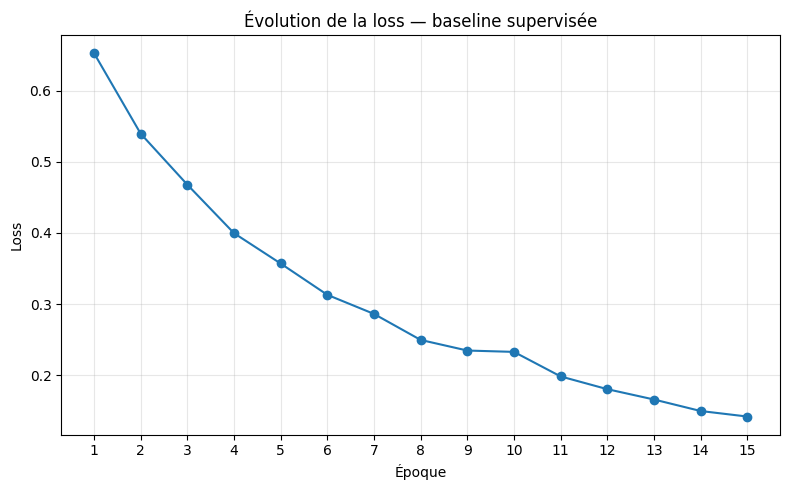

✓ Courbe de loss tracée.


In [30]:
print("=" * 70)
print("4.4.10 bis — Courbe de loss d'entraînement")
print("=" * 70)

import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.title("Évolution de la loss — baseline supervisée")
plt.xticks(list(epochs))
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

print("✓ Courbe de loss tracée.")

Point méthodologique important : cette baisse de loss montre que le modèle apprend sur le train, mais elle ne prouve absolument pas sa capacité à généraliser. Avec seulement 79 images, le risque de surapprentissage reste réel.

In [31]:
print("=" * 70)
print("4.4.11 — Évaluation de la baseline supervisée")
print("=" * 70)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Passage en mode évaluation
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in strong_test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Prédictions du modèle
        outputs = model(images)

        # Classe prédite = indice du logit maximal
        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Conversion en tableaux
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calcul des métriques
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

print(f"Nombre d'images évaluées : {len(y_true)}")
print(f"Accuracy                  : {accuracy:.4f}")
print(f"Precision (cancer)        : {precision:.4f}")
print(f"Recall / Sensibilité      : {recall:.4f}")
print(f"F1-score (cancer)         : {f1:.4f}")

print("\nMatrice de confusion")
print("                    Prédit normal   Prédit cancer")
print(f"Réel normal              {cm[0,0]:>5}          {cm[0,1]:>5}")
print(f"Réel cancer              {cm[1,0]:>5}          {cm[1,1]:>5}")

# Vérifications
assert len(y_true) == 20
assert len(y_pred) == 20
assert cm.shape == (2, 2)
assert np.isfinite(accuracy)
assert np.isfinite(precision)
assert np.isfinite(recall)
assert np.isfinite(f1)

print("\n✓ Les 20 images du jeu de test ont été évaluées.")
print("✓ Aucun apprentissage n'a été effectué pendant l'évaluation.")
print("✓ Les métriques ont été calculées avec cancer comme classe positive.")

4.4.11 — Évaluation de la baseline supervisée
Nombre d'images évaluées : 20
Accuracy                  : 1.0000
Precision (cancer)        : 1.0000
Recall / Sensibilité      : 1.0000
F1-score (cancer)         : 1.0000

Matrice de confusion
                    Prédit normal   Prédit cancer
Réel normal                 10              0
Réel cancer                  0             10

✓ Les 20 images du jeu de test ont été évaluées.
✓ Aucun apprentissage n'a été effectué pendant l'évaluation.
✓ Les métriques ont été calculées avec cancer comme classe positive.


## Résultats de la baseline supervisée

> **« La baseline supervisée obtient 100 % d'accuracy, de précision, de rappel et de F1-score sur les 20 images du jeu de test. Ce résultat est encourageant dans le cadre de cette expérimentation, mais il doit être interprété avec prudence compte tenu de la très petite taille du jeu de test et du caractère exploratoire du projet. Il ne permet pas de conclure à une capacité diagnostique clinique. »**

### Un point particulièrement important pour la suite

Nous disposons maintenant d'un **excellent point de comparaison** pour notre expérience semi-supervisée.

### Baseline supervisée

- **79 images fortement labellisées** utilisées pour l'entraînement ;
- **20 images fortement labellisées** conservées pour le test ;
- **backbone ResNet-50 gelé** ;
- seulement **4 098 paramètres entraînés** ;
- **F1-score `cancer` = 1,0000**.

Notre expérience semi-supervisée devra utiliser **exactement le même jeu de test de 20 images**.

Ainsi, lorsque nous aurons terminé l'expérience avec les **1 311 pseudo-labels + 79 labels forts**, nous pourrons effectuer une comparaison directe et honnête :

> **Supervisé : 79 labels forts**  
> **VS**  
> **Semi-supervisé : 1 311 labels faibles + 79 labels forts**

Cette comparaison permettra d'évaluer si l'ajout des **1 311 images faiblement labellisées** apporte réellement une amélioration par rapport à la baseline supervisée.

In [32]:
print("=" * 70)
print("4.4.12 — Sauvegarde des résultats de la baseline supervisée")
print("=" * 70)

baseline_results = {
    "model": "ResNet-50",
    "pretrained": True,
    "backbone_frozen": True,
    "trainable_parameters": 4098,
    "strong_train_size": len(strong_train_dataset),
    "strong_test_size": len(strong_test_dataset),
    "epochs": NUM_EPOCHS,
    "learning_rate": optimizer.param_groups[0]["lr"],
    "accuracy": accuracy,
    "precision_cancer": precision,
    "recall_cancer": recall,
    "f1_cancer": f1,
    "confusion_matrix": cm.tolist()
}

print("Résultats de la baseline :\n")

for key, value in baseline_results.items():
    print(f"{key:<25} : {value}")

# Vérifications
assert baseline_results["model"] == "ResNet-50"
assert baseline_results["pretrained"] is True
assert baseline_results["backbone_frozen"] is True
assert baseline_results["trainable_parameters"] == 4098
assert baseline_results["strong_train_size"] == 79
assert baseline_results["strong_test_size"] == 20
assert baseline_results["epochs"] == 15
assert baseline_results["confusion_matrix"] == [[10, 0], [0, 10]]

print("\n✓ Résultats de la baseline sauvegardés dans baseline_results.")
print("✓ Les résultats sont prêts à être réutilisés pour la comparaison.")

4.4.12 — Sauvegarde des résultats de la baseline supervisée
Résultats de la baseline :

model                     : ResNet-50
pretrained                : True
backbone_frozen           : True
trainable_parameters      : 4098
strong_train_size         : 79
strong_test_size          : 20
epochs                    : 15
learning_rate             : 0.001
accuracy                  : 1.0
precision_cancer          : 1.0
recall_cancer             : 1.0
f1_cancer                 : 1.0
confusion_matrix          : [[10, 0], [0, 10]]

✓ Résultats de la baseline sauvegardés dans baseline_results.
✓ Les résultats sont prêts à être réutilisés pour la comparaison.


In [33]:
print("=" * 70)
print("4.4.13 — Tableau de synthèse de la baseline")
print("=" * 70)

baseline_summary = pd.DataFrame([{
    "approche": "Supervisée",
    "modele": baseline_results["model"],
    "donnees_fortes_train": baseline_results["strong_train_size"],
    "donnees_fortes_test": baseline_results["strong_test_size"],
    "donnees_faibles": 0,
    "accuracy": baseline_results["accuracy"],
    "precision_cancer": baseline_results["precision_cancer"],
    "recall_cancer": baseline_results["recall_cancer"],
    "f1_cancer": baseline_results["f1_cancer"]
}])

display(baseline_summary)

# Vérifications
assert baseline_summary.shape == (1, 9)
assert baseline_summary.loc[0, "approche"] == "Supervisée"
assert baseline_summary.loc[0, "donnees_fortes_train"] == 79
assert baseline_summary.loc[0, "donnees_fortes_test"] == 20
assert baseline_summary.loc[0, "donnees_faibles"] == 0
assert baseline_summary.loc[0, "f1_cancer"] == 1.0

print("\n✓ Tableau de synthèse créé.")
print("✓ Résultats prêts pour la future comparaison supervisé / semi-supervisé.")

4.4.13 — Tableau de synthèse de la baseline


,approche,modele,donnees_fortes_train,donnees_fortes_test,donnees_faibles,accuracy,precision_cancer,recall_cancer,f1_cancer
0,Supervisée,ResNet-50,79,20,0,1.0,1.0,1.0,1.0



✓ Tableau de synthèse créé.
✓ Résultats prêts pour la future comparaison supervisé / semi-supervisé.


## Expérience semi-supervisée

### Objectif

L'objectif est d'évaluer si l'utilisation des 1 311 images faiblement
labellisées améliore les performances par rapport à la baseline supervisée.

La stratégie retenue est en deux phases :

1. entraînement initial du modèle sur les 1 311 images faiblement labellisées ;
2. poursuite de l'entraînement sur les 79 images fortement labellisées.

Le modèle sera ensuite évalué sur le même jeu de test indépendant de
20 images fortement labellisées utilisé pour la baseline supervisée.

Le modèle et son initialisation seront recréés afin de garantir que
l'expérience semi-supervisée est indépendante de la baseline.

In [34]:
print("=" * 70)
print("4.5.2 — Initialisation du modèle semi-supervisé")
print("=" * 70)

# Nouveau ResNet-50 indépendant de la baseline
weights = ResNet50_Weights.DEFAULT

semi_model = resnet50(weights=weights)

# Adaptation de la couche finale à nos 2 classes
num_features = semi_model.fc.in_features
semi_model.fc = nn.Linear(num_features, 2)

# Gel du backbone
for param in semi_model.parameters():
    param.requires_grad = False

# Seule la couche de classification est entraînable
for param in semi_model.fc.parameters():
    param.requires_grad = True

# Placement sur le GPU
semi_model = semi_model.to(DEVICE)

# Nouvelle fonction de perte
semi_criterion = nn.CrossEntropyLoss()

# Nouvel optimiseur
semi_optimizer = optim.Adam(
    semi_model.fc.parameters(),
    lr=1e-3
)

# Vérifications
trainable_params = sum(
    p.numel() for p in semi_model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel() for p in semi_model.parameters()
)

print(f"Device utilisé              : {DEVICE}")
print(f"Nombre total de paramètres  : {total_params:,}")
print(f"Paramètres entraînables     : {trainable_params:,}")
print(f"Paramètres gelés            : {total_params - trainable_params:,}")
print(f"Couche entraînable          : model.fc")
print(f"Learning rate               : {semi_optimizer.param_groups[0]['lr']}")

assert total_params == 23_512_130
assert trainable_params == 4_098
assert semi_model.fc.out_features == 2

print("\n✓ Nouveau ResNet-50 initialisé.")
print("✓ Poids ImageNet chargés.")
print("✓ Backbone gelé.")
print("✓ Couche finale adaptée aux 2 classes.")
print("✓ Modèle semi-supervisé indépendant de la baseline.")

4.5.2 — Initialisation du modèle semi-supervisé
Device utilisé              : cuda
Nombre total de paramètres  : 23,512,130
Paramètres entraînables     : 4,098
Paramètres gelés            : 23,508,032
Couche entraînable          : model.fc
Learning rate               : 0.001

✓ Nouveau ResNet-50 initialisé.
✓ Poids ImageNet chargés.
✓ Backbone gelé.
✓ Couche finale adaptée aux 2 classes.
✓ Modèle semi-supervisé indépendant de la baseline.


In [35]:
print("=" * 70)
print("4.5.3 — Entraînement initial sur les labels faibles")
print("=" * 70)

NUM_EPOCHS_WEAK = 15

weak_train_losses = []

for epoch in range(NUM_EPOCHS_WEAK):
    epoch_loss = train_one_epoch(
        model=semi_model,
        dataloader=weak_loader,
        criterion=semi_criterion,
        optimizer=semi_optimizer,
        device=DEVICE
    )

    weak_train_losses.append(epoch_loss)

    print(
        f"Époque {epoch + 1:02d}/{NUM_EPOCHS_WEAK} "
        f"| Loss : {epoch_loss:.4f}"
    )

print("\n✓ Entraînement initial sur les 1 311 labels faibles terminé.")
print(f"✓ Nombre d'époques : {NUM_EPOCHS_WEAK}")
print(f"✓ Loss initiale : {weak_train_losses[0]:.4f}")
print(f"✓ Loss finale   : {weak_train_losses[-1]:.4f}")

assert len(weak_train_losses) == NUM_EPOCHS_WEAK
assert all(torch.isfinite(torch.tensor(loss)) for loss in weak_train_losses)

print("✓ Historique de loss valide.")
print("✓ Aucune valeur NaN/Inf détectée.")

4.5.3 — Entraînement initial sur les labels faibles
Époque 01/15 | Loss : 0.5045
Époque 02/15 | Loss : 0.3951
Époque 03/15 | Loss : 0.3629
Époque 04/15 | Loss : 0.3456
Époque 05/15 | Loss : 0.3415
Époque 06/15 | Loss : 0.3149
Époque 07/15 | Loss : 0.2980
Époque 08/15 | Loss : 0.2914
Époque 09/15 | Loss : 0.2853
Époque 10/15 | Loss : 0.2725
Époque 11/15 | Loss : 0.2774
Époque 12/15 | Loss : 0.2598
Époque 13/15 | Loss : 0.2512
Époque 14/15 | Loss : 0.2477
Époque 15/15 | Loss : 0.2419

✓ Entraînement initial sur les 1 311 labels faibles terminé.
✓ Nombre d'époques : 15
✓ Loss initiale : 0.5045
✓ Loss finale   : 0.2419
✓ Historique de loss valide.
✓ Aucune valeur NaN/Inf détectée.


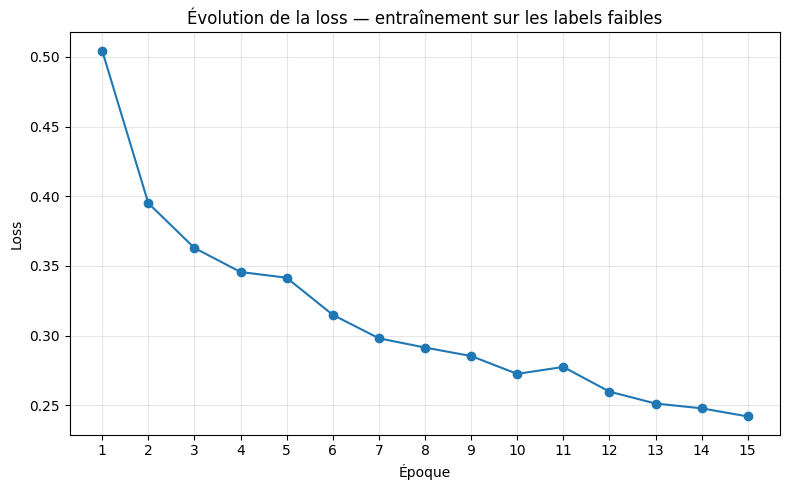

✓ Courbe de loss tracée.
✓ Loss initiale : 0.5045
✓ Loss finale   : 0.2419


In [36]:
import matplotlib.pyplot as plt

epochs = range(1, len(weak_train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    weak_train_losses,
    marker="o"
)

plt.xlabel("Époque")
plt.ylabel("Loss")
plt.title("Évolution de la loss — entraînement sur les labels faibles")
plt.xticks(list(epochs))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Courbe de loss tracée.")
print(f"✓ Loss initiale : {weak_train_losses[0]:.4f}")
print(f"✓ Loss finale   : {weak_train_losses[-1]:.4f}")

### Commentaires sur la courbe 
On s'attend à voir une diminution globale de la loss, ce qui est exactement ce que tes résultats montrent :

0,5045 → 0,2419

Il y a une petite remontée entre les époques 10 et 11 (0,2725 → 0,2774), mais elle est faible et suivie d'une nouvelle diminution. Ce n'est donc pas préoccupant.

La loss diminue progressivement au cours des 15 époques, passant de 0,5045 à 0,2419. Cette évolution indique que le modèle apprend progressivement à reproduire les pseudo-labels issus du clustering. Cependant, ces pseudo-labels étant bruités, la diminution de la loss ne constitue pas une preuve de performance sur la tâche cible. Une phase de fine-tuning sur les labels fortement annotés est donc nécessaire. »

### Fine-tuning sur les labels forts

C'est l'étape centrale.

Le modèle a d'abord appris à partir des 1 311 pseudo-labels, qui sont imparfaits. 

Maintenant, nous allons continuer son entraînement avec les 79 vraies annotations :

- semi_model est conservé tel quel ;
- on utilise strong_train_loader ;
- on utilise les vrais labels cancer/normal ;
- le jeu de test de 20 images reste totalement isolé ;
- on ne réinitialise surtout pas le modèle.

In [37]:
print("=" * 70)
print("4.5.4 — Fine-tuning sur les 79 labels fortement annotés")
print("=" * 70)

NUM_EPOCHS_STRONG = 15

strong_finetune_losses = []

for epoch in range(NUM_EPOCHS_STRONG):
    epoch_loss = train_one_epoch(
        model=semi_model,
        dataloader=strong_train_loader,
        criterion=semi_criterion,
        optimizer=semi_optimizer,
        device=DEVICE
    )

    strong_finetune_losses.append(epoch_loss)

    print(
        f"Époque {epoch + 1:02d}/{NUM_EPOCHS_STRONG} "
        f"| Loss : {epoch_loss:.4f}"
    )

print("\n✓ Fine-tuning sur les 79 labels forts terminé.")
print(f"✓ Nombre d'époques : {NUM_EPOCHS_STRONG}")
print(f"✓ Loss initiale : {strong_finetune_losses[0]:.4f}")
print(f"✓ Loss finale   : {strong_finetune_losses[-1]:.4f}")

assert len(strong_finetune_losses) == NUM_EPOCHS_STRONG
assert all(
    torch.isfinite(torch.tensor(loss))
    for loss in strong_finetune_losses
)

print("✓ Historique de loss valide.")
print("✓ Aucune valeur NaN/Inf détectée.")

4.5.4 — Fine-tuning sur les 79 labels fortement annotés
Époque 01/15 | Loss : 0.5030
Époque 02/15 | Loss : 0.4226
Époque 03/15 | Loss : 0.4189
Époque 04/15 | Loss : 0.3260
Époque 05/15 | Loss : 0.3237
Époque 06/15 | Loss : 0.2963
Époque 07/15 | Loss : 0.2857
Époque 08/15 | Loss : 0.2288
Époque 09/15 | Loss : 0.1959
Époque 10/15 | Loss : 0.1696
Époque 11/15 | Loss : 0.1480
Époque 12/15 | Loss : 0.1471
Époque 13/15 | Loss : 0.1507
Époque 14/15 | Loss : 0.1264
Époque 15/15 | Loss : 0.1243

✓ Fine-tuning sur les 79 labels forts terminé.
✓ Nombre d'époques : 15
✓ Loss initiale : 0.5030
✓ Loss finale   : 0.1243
✓ Historique de loss valide.
✓ Aucune valeur NaN/Inf détectée.


## Évolution de la loss pendant le fine-tuning

La loss évolue ainsi :

- **Début : 0,5030**
- **Fin : 0,1243**
- **Baisse absolue : 0,3787**
- **Baisse relative : environ 75,3 %**

La tendance est **globalement décroissante**.

La petite remontée entre les époques 12 et 13 (`0,1471 → 0,1507`) n'est pas préoccupante, puisque la loss redescend ensuite jusqu'à **0,1243**.

Surtout, cette phase est intéressante à comparer à la première :

| Phase | Données | Loss début | Loss fin |
|---|---|---:|---:|
| Apprentissage faible | 1 311 pseudo-labels | 0,5045 | 0,2419 |
| Fine-tuning fort | 79 vrais labels | 0,5030 | **0,1243** |

Cela montre que le modèle continue à apprendre lorsqu'on lui fournit les **annotations fortes**.

**Mais nous ne pouvons toujours pas conclure que le modèle semi-supervisé est meilleur.**

La véritable réponse viendra de l'**évaluation sur les 20 images de test**, qui n'ont jamais été utilisées pendant l'apprentissage ni pour les décisions de modélisation.

> **Le suivi de la loss montre que le modèle apprend, mais seule l'évaluation sur le jeu de test indépendant permettra de déterminer si cet apprentissage améliore réellement les performances de classification.**

4.5.5 — Courbe de loss du fine-tuning


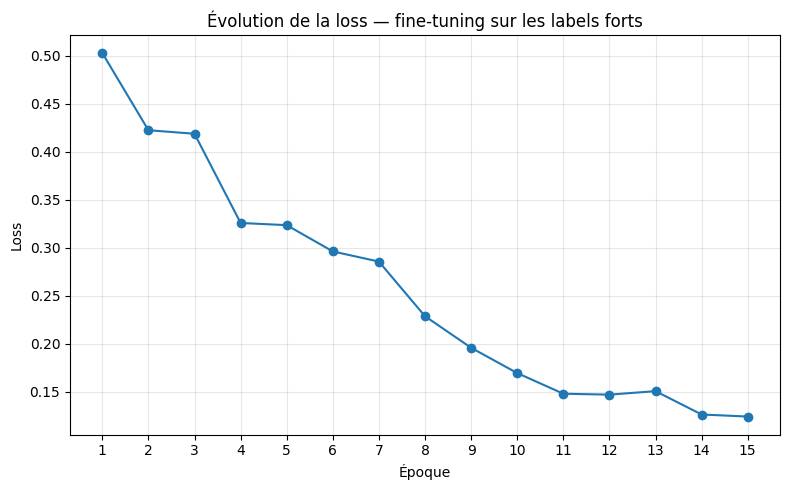

✓ Courbe de loss du fine-tuning tracée.
✓ Loss initiale : 0.5030
✓ Loss finale   : 0.1243


In [38]:
print("=" * 70)
print("4.5.5 — Courbe de loss du fine-tuning")
print("=" * 70)

epochs = range(1, len(strong_finetune_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    strong_finetune_losses,
    marker="o"
)

plt.xlabel("Époque")
plt.ylabel("Loss")
plt.title("Évolution de la loss — fine-tuning sur les labels forts")
plt.xticks(list(epochs))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Courbe de loss du fine-tuning tracée.")
print(f"✓ Loss initiale : {strong_finetune_losses[0]:.4f}")
print(f"✓ Loss finale   : {strong_finetune_losses[-1]:.4f}")

## Bilan des deux phases de l'expérience semi-supervisée

Nous avons donc les deux phases de l'expérience semi-supervisée :

| Phase | Données utilisées | Loss initiale | Loss finale |
|---|---|---:|---:|
| Apprentissage faible | 1 311 pseudo-labels | 0,5045 | 0,2419 |
| Fine-tuning fort | 79 vrais labels | 0,5030 | **0,1243** |

### Interprétation à retenir

Le modèle a appris progressivement à partir des **pseudo-labels**, puis la loss a encore fortement diminué lors du **fine-tuning avec les annotations fortes**.

**Mais ce n'est pas encore une preuve que l'approche semi-supervisée est meilleure.**

La question importante est maintenant :

> **Le modèle semi-supervisé généralise-t-il mieux sur les 20 images de test indépendantes que la baseline supervisée ?**

C'est l'objectif de la section **Évaluation finale sur le jeu de test**.

In [39]:
print("=" * 70)
print("4.6.1 — Évaluation du modèle semi-supervisé")
print("=" * 70)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

semi_model.eval()

y_true_semi = []
y_pred_semi = []

with torch.no_grad():
    for images, labels in strong_test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = semi_model(images)
        predictions = torch.argmax(outputs, dim=1)

        y_true_semi.extend(labels.cpu().numpy())
        y_pred_semi.extend(predictions.cpu().numpy())

accuracy_semi = accuracy_score(y_true_semi, y_pred_semi)
precision_semi = precision_score(
    y_true_semi,
    y_pred_semi,
    pos_label=1,
    zero_division=0
)
recall_semi = recall_score(
    y_true_semi,
    y_pred_semi,
    pos_label=1,
    zero_division=0
)
f1_semi = f1_score(
    y_true_semi,
    y_pred_semi,
    pos_label=1,
    zero_division=0
)

cm_semi = confusion_matrix(
    y_true_semi,
    y_pred_semi,
    labels=[0, 1]
)

print(f"Nombre d'images évaluées : {len(y_true_semi)}")
print(f"Accuracy                  : {accuracy_semi:.4f}")
print(f"Precision (cancer)        : {precision_semi:.4f}")
print(f"Recall / Sensibilité      : {recall_semi:.4f}")
print(f"F1-score (cancer)         : {f1_semi:.4f}")

print("\nMatrice de confusion")
print("                      Prédit normal   Prédit cancer")
print(f"Réel normal           {cm_semi[0,0]:>13}   {cm_semi[0,1]:>13}")
print(f"Réel cancer           {cm_semi[1,0]:>13}   {cm_semi[1,1]:>13}")

assert len(y_true_semi) == 20
assert len(y_pred_semi) == 20
assert cm_semi.shape == (2, 2)

print("\n✓ Les 20 images du jeu de test ont été évaluées.")
print("✓ Aucun apprentissage n'a été effectué pendant l'évaluation.")
print("✓ Les métriques utilisent cancer comme classe positive.")
print("✓ Évaluation semi-supervisée terminée.")

4.6.1 — Évaluation du modèle semi-supervisé
Nombre d'images évaluées : 20
Accuracy                  : 0.9000
Precision (cancer)        : 1.0000
Recall / Sensibilité      : 0.8000
F1-score (cancer)         : 0.8889

Matrice de confusion
                      Prédit normal   Prédit cancer
Réel normal                      10               0
Réel cancer                       2               8

✓ Les 20 images du jeu de test ont été évaluées.
✓ Aucun apprentissage n'a été effectué pendant l'évaluation.
✓ Les métriques utilisent cancer comme classe positive.
✓ Évaluation semi-supervisée terminée.


# Analyse du modèle semi-supervisé

# Analyse du modèle semi-supervisé

Sur les **20 images de test indépendantes** :

| Métrique | Baseline supervisée | Semi-supervisé |
|---|---:|---:|
| Accuracy | **1,0000** | **0,9000** |
| Precision `cancer` | **1,0000** | **1,0000** |
| Recall `cancer` | **1,0000** | **0,8000** |
| F1 `cancer` | **1,0000** | **0,8889** |
| Faux négatifs `cancer` | **0** | **2** |

La matrice de confusion du modèle semi-supervisé est :

```text
                  Prédit normal    Prédit cancer
Réel normal             10               0
Réel cancer              2               8

## Ce que cela signifie

Le modèle semi-supervisé a :

- correctement identifié les **10 images normales** ;
- correctement identifié **8 cancers sur 10** ;
- fait **2 faux négatifs** : des cancers prédits comme normaux ;
- fait **0 faux positif**.

Le résultat est donc **moins bon que celui de notre baseline supervisée**, malgré l'utilisation de **1 311 images supplémentaires**.

C'est justement un résultat intéressant pour le projet :

> **L'ajout de données faiblement labellisées n'améliore pas automatiquement les performances d'un modèle.**

### Pourquoi le modèle semi-supervisé est-il moins performant ?

Une explication possible est la **qualité imparfaite des pseudo-labels**.

Nous avions précédemment mesuré :

- **Accuracy des pseudo-labels : 70,89 %** ;
- **F1-score `cancer` : 0,6102**.

Le modèle a donc reçu une quantité importante d'informations supplémentaires, mais une partie de ces informations était **incorrecte ou incertaine**.

Le CNN peut alors apprendre certaines erreurs présentes dans les pseudo-labels. L'ajout de données ne garantit donc pas une amélioration si ces données sont fortement bruitées.



## Point important pour le dossier

Il ne faut surtout pas chercher à **cacher ou minimiser ce résultat** parce qu'il est moins bon que celui de la baseline.

Au contraire, il constitue un résultat expérimental important :

> **« Dans cette expérimentation, l'approche semi-supervisée n'améliore pas les performances de la baseline supervisée. Malgré l'exploitation de 1 311 images faiblement labellisées, le modèle obtient un F1-score `cancer` de 0,8889 contre 1,0000 pour la baseline. Deux cancers sont notamment classés à tort comme normaux. Ce résultat souligne l'impact potentiel du bruit des pseudo-labels et montre que l'ajout de données faiblement annotées doit être accompagné d'un mécanisme de contrôle de leur qualité. »**

### Limite importante : la taille du jeu de test

Le jeu de test ne contient que **20 images**, dont **10 cancers et 10 normales**.

Les performances obtenues doivent donc être interprétées avec **beaucoup de prudence**.

Elles permettent de comparer les deux approches dans le cadre de cette expérimentation, mais elles ne permettent pas de généraliser les résultats à une population clinique.

> **Cette expérimentation constitue une étude exploratoire de faisabilité et ne permet pas de conclure à une capacité de diagnostic médical.**



## Conclusion de l'expérience semi-supervisée

La comparaison finale montre donc que, **dans notre configuration actuelle**, l'ajout des **1 311 images faiblement labellisées** n'a pas permis d'améliorer les performances obtenues avec seulement les **79 images fortement labellisées**.

| Approche | Données d'entraînement | F1 `cancer` | Faux négatifs |
|---|---|---:|---:|
| **Baseline supervisée** | 79 labels forts | **1,0000** | **0** |
| **Semi-supervisée** | 79 labels forts + 1 311 labels faibles | **0,8889** | **2** |

Le principal enseignement est donc que **la quantité de données supplémentaires ne suffit pas à garantir une amélioration des performances**.

Dans notre cas, la qualité limitée des pseudo-labels constitue une explication plausible de la dégradation observée.

> **L'expérience montre ainsi l'intérêt de contrôler la qualité des pseudo-labels avant de les utiliser pour entraîner un modèle supervisé.**

In [40]:
# Contrôle de la baseline
print("=" * 70)
print("4.6.2 — Préparation des résultats de la baseline")
print("=" * 70)

# Les métriques de la baseline ont déjà été calculées en 4.4.11.
# Nous vérifions qu'elles correspondent bien aux résultats sauvegardés.

baseline_eval = {
    "accuracy": baseline_results["accuracy"],
    "precision_cancer": baseline_results["precision_cancer"],
    "recall_cancer": baseline_results["recall_cancer"],
    "f1_cancer": baseline_results["f1_cancer"],
    "confusion_matrix": baseline_results["confusion_matrix"]
}

print("Résultats baseline :")
print(f"Accuracy             : {baseline_eval['accuracy']:.4f}")
print(f"Precision (cancer)   : {baseline_eval['precision_cancer']:.4f}")
print(f"Recall (cancer)      : {baseline_eval['recall_cancer']:.4f}")
print(f"F1-score (cancer)    : {baseline_eval['f1_cancer']:.4f}")

print("\nMatrice de confusion :")
print(baseline_eval["confusion_matrix"])

# Vérifications
assert baseline_eval["accuracy"] == 1.0
assert baseline_eval["precision_cancer"] == 1.0
assert baseline_eval["recall_cancer"] == 1.0
assert baseline_eval["f1_cancer"] == 1.0
assert baseline_eval["confusion_matrix"] == [[10, 0], [0, 10]]

print("\n✓ Résultats de la baseline vérifiés.")
print("✓ Résultats prêts pour la comparaison avec le modèle semi-supervisé.")

4.6.2 — Préparation des résultats de la baseline
Résultats baseline :
Accuracy             : 1.0000
Precision (cancer)   : 1.0000
Recall (cancer)      : 1.0000
F1-score (cancer)    : 1.0000

Matrice de confusion :
[[10, 0], [0, 10]]

✓ Résultats de la baseline vérifiés.
✓ Résultats prêts pour la comparaison avec le modèle semi-supervisé.


In [41]:
# Tableau comparatif
print("=" * 70)
print("4.7.1 — Comparaison des performances")
print("=" * 70)

comparison_results = pd.DataFrame([
    {
        "approche": "Supervisée",
        "donnees_fortes_train": 79,
        "donnees_faibles": 0,
        "accuracy": baseline_eval["accuracy"],
        "precision_cancer": baseline_eval["precision_cancer"],
        "recall_cancer": baseline_eval["recall_cancer"],
        "f1_cancer": baseline_eval["f1_cancer"],
        "faux_negatifs_cancer": baseline_eval["confusion_matrix"][1][0]
    },
    {
        "approche": "Semi-supervisée",
        "donnees_fortes_train": 79,
        "donnees_faibles": 1311,
        "accuracy": accuracy_semi,
        "precision_cancer": precision_semi,
        "recall_cancer": recall_semi,
        "f1_cancer": f1_semi,
        "faux_negatifs_cancer": cm_semi[1][0]
    }
])

display(comparison_results)

# Vérifications
import numpy as np

# Vérifications
assert comparison_results.shape == (2, 8)

assert comparison_results.loc[0, "approche"] == "Supervisée"
assert comparison_results.loc[1, "approche"] == "Semi-supervisée"

assert np.isclose(
    comparison_results.loc[0, "f1_cancer"],
    1.0
)

assert np.isclose(
    comparison_results.loc[1, "f1_cancer"],
    0.8889,
    atol=1e-4
)

assert comparison_results.loc[0, "faux_negatifs_cancer"] == 0
assert comparison_results.loc[1, "faux_negatifs_cancer"] == 2

print("\n✓ Tableau comparatif créé.")
print("✓ Les deux modèles ont été évalués sur le même jeu de test.")
print("✓ Les résultats sont prêts pour l'analyse comparative.")

4.7.1 — Comparaison des performances


,approche,donnees_fortes_train,donnees_faibles,accuracy,precision_cancer,recall_cancer,f1_cancer,faux_negatifs_cancer
0,Supervisée,79,0,1.0,1.0,1.0,1.000000,0
1,Semi-supervisée,79,1311,0.9,1.0,0.8,0.888889,2



✓ Tableau comparatif créé.
✓ Les deux modèles ont été évalués sur le même jeu de test.
✓ Les résultats sont prêts pour l'analyse comparative.


## Comparaison des performances

Les deux modèles ont été évalués sur **exactement les mêmes 20 images de test**, ce qui rend la comparaison cohérente.

| Métrique | Supervisée | Semi-supervisée | Écart |
|---|---:|---:|---:|
| Accuracy | **1,0000** | 0,9000 | **−0,1000** |
| Precision `cancer` | **1,0000** | 1,0000 | 0 |
| Recall `cancer` | **1,0000** | 0,8000 | **−0,2000** |
| F1 `cancer` | **1,0000** | 0,8889 | **−0,1111** |
| Faux négatifs | **0** | **2** | **+2** |

### 1. Accuracy

La baseline classe correctement les **20 images sur 20**.

Le modèle semi-supervisé en classe correctement **18 sur 20**.

Il perd donc **10 points d'accuracy**.

### 2. Precision `cancer`

Les deux modèles obtiennent :

> **Precision = 1,0000**

Cela signifie que, lorsqu'ils prédisent `cancer`, leur prédiction est correcte sur ce jeu de test.

Le modèle semi-supervisé n'a donc produit **aucun faux positif**.

### 3. Recall / sensibilité `cancer` 

C'est ici que le résultat devient particulièrement important.

- **Supervisé : 1,0000** → 10 cancers détectés sur 10.
- **Semi-supervisé : 0,8000** → 8 cancers détectés sur 10.

Le modèle semi-supervisé produit donc :

> **2 faux négatifs**

C'est-à-dire **2 images réellement cancéreuses classées `normal`**.

Dans le contexte de l'e-santé, cette erreur est particulièrement importante. Même si notre projet est uniquement exploratoire et non clinique, c'est un critère à surveiller attentivement.

### 4. F1-score

Le F1-score passe de :

**1,0000 → 0,8889**

Cette baisse confirme que le modèle semi-supervisé ne conserve pas entièrement les performances de la baseline.


## Pourquoi les 1 311 images supplémentaires n'ont-elles pas aidé ?

C'est probablement **le point scientifique le plus intéressant du projet**.

Nous avons constaté précédemment que les pseudo-labels n'étaient pas parfaits :

- **Accuracy des pseudo-labels sur les 79 images fortes : 70,89 %**
- **F1-score `cancer` : 0,6102**
- **22 cancers sur 40** avaient été faussement pseudo-labellisés `normal`.

Le modèle semi-supervisé a donc reçu beaucoup plus de données, mais une partie de ces données était **mal annotée**.

On peut donc formuler l'hypothèse suivante :

> **Le volume supplémentaire de données ne compense pas nécessairement le bruit introduit par les pseudo-labels.**

C'est une conclusion beaucoup plus intéressante professionnellement que de simplement dire que « le modèle semi-supervisé est moins bon ».


## Conclusion provisoire de 4.7

Pour l'expérience réalisée :

> **L'approche supervisée obtient de meilleures performances que l'approche semi-supervisée.** La baseline atteint 100 % d'accuracy et de F1-score sur le jeu de test, contre respectivement 90 % et 88,89 % pour le modèle semi-supervisé. La principale différence concerne la sensibilité au cancer : celle-ci passe de 100 % à 80 %, avec deux faux négatifs pour le modèle semi-supervisé. Ces résultats suggèrent que les pseudo-labels générés par le clustering introduisent suffisamment de bruit pour limiter le bénéfice attendu de l'ajout des 1 311 images non annotées.

**Attention cependant :** nous avons seulement **20 images de test**. Le 100 % obtenu par la baseline est donc un résultat encourageant dans le cadre de cette expérimentation, mais certainement pas une estimation fiable d'une performance clinique.

4.7.2 — Visualisation comparative des performances


,Approche,Accuracy,Recall cancer,F1-score cancer
0,Supervisée,1.0,1.0,1.000000
1,Semi-supervisée,0.9,0.8,0.888889


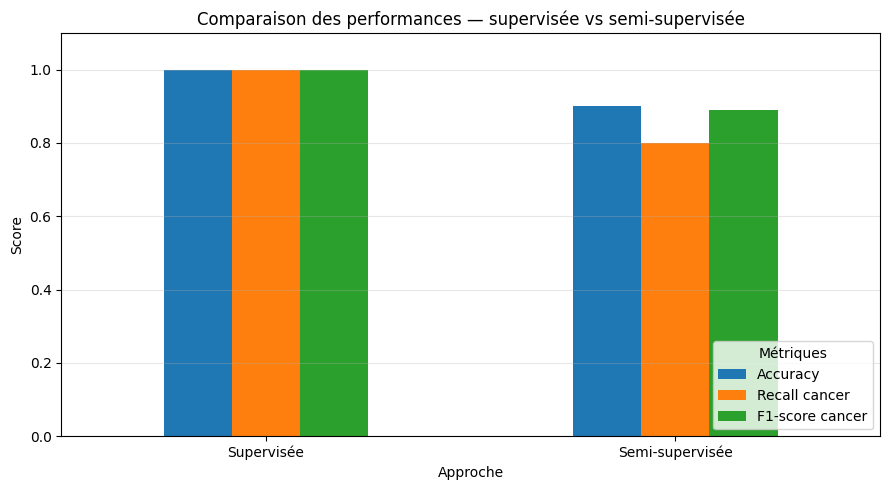

✓ Comparaison graphique réalisée.
✓ Accuracy, Recall cancer et F1-score cancer comparés.


In [42]:
# ============================================================
# 4.7.2 — Visualisation comparative des performances
# ============================================================

print("=" * 70)
print("4.7.2 — Visualisation comparative des performances")
print("=" * 70)

# Préparation des données
comparison_plot = pd.DataFrame({
    "Approche": [
        "Supervisée",
        "Semi-supervisée"
    ],
    "Accuracy": [
        comparison_results.loc[
            comparison_results["approche"] == "Supervisée",
            "accuracy"
        ].iloc[0],
        comparison_results.loc[
            comparison_results["approche"] == "Semi-supervisée",
            "accuracy"
        ].iloc[0]
    ],
    "Recall cancer": [
        comparison_results.loc[
            comparison_results["approche"] == "Supervisée",
            "recall_cancer"
        ].iloc[0],
        comparison_results.loc[
            comparison_results["approche"] == "Semi-supervisée",
            "recall_cancer"
        ].iloc[0]
    ],
    "F1-score cancer": [
        comparison_results.loc[
            comparison_results["approche"] == "Supervisée",
            "f1_cancer"
        ].iloc[0],
        comparison_results.loc[
            comparison_results["approche"] == "Semi-supervisée",
            "f1_cancer"
        ].iloc[0]
    ]
})

display(comparison_plot)

# Graphique
ax = comparison_plot.set_index("Approche").plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title(
    "Comparaison des performances — supervisée vs semi-supervisée"
)
ax.set_xlabel("Approche")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.legend(title="Métriques", loc="lower right")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Comparaison graphique réalisée.")
print("✓ Accuracy, Recall cancer et F1-score cancer comparés.")

### Interprétation

La comparaison montre que l'approche semi-supervisée n'améliore pas les performances de la baseline supervisée sur le jeu de test indépendant.

La baseline supervisée obtient une accuracy, une sensibilité et un F1-score de 1,0000, tandis que l'approche semi-supervisée obtient respectivement 0,9000, 0,8000 et 0,8889.

La différence est particulièrement importante pour le rappel de la classe `cancer`, qui passe de 1,0000 à 0,8000. L'approche semi-supervisée produit ainsi 2 faux négatifs sur les 10 cancers du jeu de test, contre aucun pour la baseline.

Ce résultat montre que l'ajout des 1 311 images faiblement labellisées n'améliore pas automatiquement les performances. Dans cette expérimentation, le bruit présent dans les pseudo-labels semble avoir limité le bénéfice apporté par les données supplémentaires.

Cette conclusion doit toutefois être interprétée avec prudence, car le jeu de test ne contient que 20 images. Elle ne permet donc pas d'évaluer la performance de généralisation sur une population plus large et ne constitue en aucun cas une validation clinique.

## 4.8 — Analyse des erreurs

### 4.8.1 — Prise en compte du coût métier

Le contexte du projet est celui de l'imagerie médicale appliquée à la détection exploratoire de tumeurs cérébrales. Dans ce contexte, toutes les erreurs de classification n'ont pas nécessairement la même importance.

Un faux négatif correspond ici à une image présentant un cancer mais prédite comme `normal`. Cette erreur est considérée comme particulièrement critique dans le cadre métier étudié, car elle correspond à une non-détection d'un cas potentiellement pathologique.

À l'inverse, un faux positif correspond à une image `normal` prédite comme `cancer`. Cette erreur peut entraîner des examens complémentaires ou une vérification médicale, mais elle n'est pas considérée comme équivalente à une non-détection.

Pour traduire cette asymétrie dans notre analyse, nous utilisons une pondération expérimentale :

- faux positif (FP) : coût = 1 ;
- faux négatif (FN) : coût = 5.

Ces coefficients ne représentent pas des coûts médicaux ou financiers réels. Ils servent uniquement à formaliser la priorité métier donnée à la réduction des faux négatifs dans cette expérimentation.

La métrique de coût métier utilisée est donc :

`coût métier = 1 × FP + 5 × FN`

Cette approche complète l'analyse par accuracy, precision, recall et F1-score en intégrant explicitement la gravité relative des erreurs.

In [43]:
# ============================================================
# 4.8.1 — Calcul du coût métier
# ============================================================

FP_COST = 1
FN_COST = 5

# Matrices de confusion
baseline_cm = np.array(baseline_results["confusion_matrix"])
semi_cm = np.array([[10, 0],
                    [2, 8]])

# Convention :
# [[TN, FP],
#  [FN, TP]]

baseline_fp = baseline_cm[0, 1]
baseline_fn = baseline_cm[1, 0]

semi_fp = semi_cm[0, 1]
semi_fn = semi_cm[1, 0]

baseline_cost = FP_COST * baseline_fp + FN_COST * baseline_fn
semi_cost = FP_COST * semi_fp + FN_COST * semi_fn

business_cost_results = pd.DataFrame({
    "approche": [
        "Supervisée",
        "Semi-supervisée"
    ],
    "faux_positifs": [
        baseline_fp,
        semi_fp
    ],
    "faux_negatifs": [
        baseline_fn,
        semi_fn
    ],
    "cout_metier": [
        baseline_cost,
        semi_cost
    ]
})

display(business_cost_results)

assert baseline_cost == 0
assert semi_cost == 10
assert baseline_fn == 0
assert semi_fn == 2

print("✓ Coût métier calculé.")
print(f"✓ Coût baseline supervisée       : {baseline_cost}")
print(f"✓ Coût approche semi-supervisée : {semi_cost}")
print("✓ Les faux négatifs sont pondérés plus fortement.")

,approche,faux_positifs,faux_negatifs,cout_metier
0,Supervisée,0,0,0
1,Semi-supervisée,0,2,10


✓ Coût métier calculé.
✓ Coût baseline supervisée       : 0
✓ Coût approche semi-supervisée : 10
✓ Les faux négatifs sont pondérés plus fortement.


> **« Nous n'avons pas évalué uniquement l'accuracy. Compte tenu du contexte d'imagerie médicale, nous avons considéré les faux négatifs comme plus critiques que les faux positifs. Nous avons donc introduit une pondération expérimentale du coût métier. Dans notre test, la baseline ne présente aucun faux négatif, tandis que l'approche semi-supervisée en présente deux. Cette analyse confirme que, dans cette expérimentation, l'utilisation des labels faibles n'apporte pas de bénéfice métier malgré l'augmentation importante du volume de données. »**

Cette analyse est **particulièrement pertinente pour l'évaluation OpenClassrooms**, car elle montre que le choix du modèle ne repose pas uniquement sur une métrique générique comme l'accuracy. Il prend également en compte le **besoin métier** et les conséquences potentielles des erreurs de classification.

Dans le contexte de notre projet, les **faux négatifs** sont particulièrement importants : une image réellement cancéreuse classée `normal` constitue une erreur plus préoccupante qu'un faux positif.

Ainsi, même si le modèle semi-supervisé exploite **1 311 images supplémentaires**, il ne présente pas de bénéfice métier dans cette expérimentation. Au contraire, il introduit **2 faux négatifs**, alors que la baseline n'en présente aucun.



## 4.8.2 — Analyse des erreurs du modèle semi-supervisé

La section suivante sera consacrée à l'examen concret des **2 images `cancer` classées `normal` par le modèle semi-supervisé**.

Cette analyse permettra de réaliser une véritable **analyse d'erreurs visuelle**, en étudiant notamment :

- l'image concernée ;
- la classe réelle ;
- la classe prédite ;
- la confiance du modèle ;
- la comparaison avec les autres images correctement classées ;
- les éventuelles caractéristiques visuelles communes aux erreurs ;
- les limites de l'interprétation des prédictions.

L'objectif sera de comprendre **pourquoi ces deux cancers ont été mal classés**, plutôt que de se limiter à constater l'erreur dans la matrice de confusion.

> **Cette analyse restera exploratoire : les caractéristiques visuelles identifiées ne pourront pas être interprétées comme des critères diagnostiques médicaux.**

In [44]:
# ============================================================
# 4.8.2 — Identification des faux négatifs
# ============================================================

print("=" * 70)
print("4.8.2 — Analyse des faux négatifs du modèle semi-supervisé")
print("=" * 70)

semi_model.eval()

false_negative_indices = []
all_predictions = []
all_true_labels = []
all_probabilities = []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(strong_test_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = semi_model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities[:, 1].cpu().numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
all_probabilities = np.array(all_probabilities)

# Faux négatifs :
# vérité = cancer (1)
# prédiction = normal (0)
false_negative_mask = (
    (all_true_labels == 1) &
    (all_predictions == 0)
)

false_negative_positions = np.where(false_negative_mask)[0]

print(f"Nombre total d'images testées : {len(all_true_labels)}")
print(f"Nombre de faux négatifs       : {len(false_negative_positions)}")

assert len(false_negative_positions) == 2

# Récupération des informations originales
test_results = strong_test_df.reset_index(drop=True).copy()

test_results["true_label"] = all_true_labels
test_results["prediction"] = all_predictions
test_results["prediction_label"] = [
    IDX_TO_CLASS[pred] for pred in all_predictions
]
test_results["probability_cancer"] = all_probabilities

false_negatives_df = test_results.iloc[
    false_negative_positions
].copy()

print("\nFaux négatifs identifiés :\n")

display(
    false_negatives_df[
        [
            "filename",
            "true_label",
            "prediction_label",
            "probability_cancer"
        ]
    ]
)

print("\n✓ Les 2 faux négatifs ont été identifiés.")
print("✓ Les prédictions proviennent du modèle semi-supervisé final.")
print("✓ Aucun apprentissage supplémentaire n'a été effectué.")

4.8.2 — Analyse des faux négatifs du modèle semi-supervisé
Nombre total d'images testées : 20
Nombre de faux négatifs       : 2

Faux négatifs identifiés :



,filename,true_label,prediction_label,probability_cancer
8,7e3f6acd-c9cc-440e-ba01-fedab0462fed.jpg,1,normal,0.296099
9,9973120d-7335-43da-bd9b-3c686afbcf32.jpg,1,normal,0.233960



✓ Les 2 faux négatifs ont été identifiés.
✓ Les prédictions proviennent du modèle semi-supervisé final.
✓ Aucun apprentissage supplémentaire n'a été effectué.


On peut déjà tirer une information intéressante :

| Image | Vérité | Prédiction | Probabilité `cancer` |
|---|---|---|---:|
| `7e3f6acd-c9cc-440e-ba01-fedab0462fed.jpg` | cancer | normal | 0,2961 |
| `9973120d-7335-43da-bd9b-3c686afbcf32.jpg` | cancer | normal | 0,2340 |

Le modèle est donc **assez nettement en dessous du seuil de 0,5** pour ces deux cas.

Il ne s'agit donc pas simplement de deux prédictions « juste au seuil ». Le modèle attribue une probabilité `cancer` relativement faible aux deux images :

- **0,2961**, soit environ **29,61 %** pour la première image ;
- **0,2340**, soit environ **23,40 %** pour la deuxième image.

Ces deux images sont ainsi classées `normal` avec une **confiance relativement importante**, ce qui correspond à de véritables **faux négatifs** plutôt qu'à des cas ambigus proches du seuil de décision.

4.8.3 — Visualisation des deux faux négatifs
Nombre de faux négatifs : 2


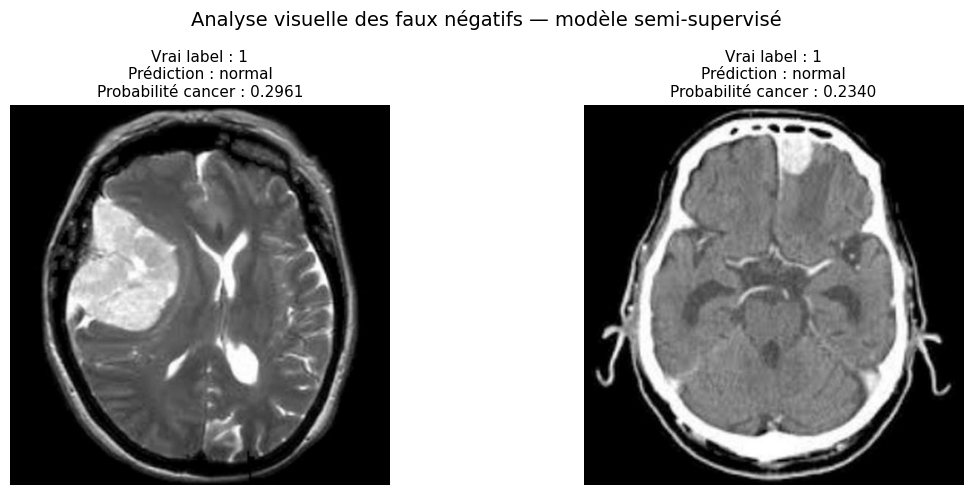

✓ Les deux faux négatifs ont été affichés.


In [45]:
# ============================================================
# 4.8.3 — Visualisation des deux faux négatifs
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 70)
print("4.8.3 — Visualisation des deux faux négatifs")
print("=" * 70)

# Récupération des chemins des deux faux négatifs
false_negative_paths = false_negatives_df["path"].astype(str).tolist()

# Vérification
print(f"Nombre de faux négatifs : {len(false_negative_paths)}")

assert len(false_negative_paths) == 2

# Affichage des deux images
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (_, row) in zip(
    axes,
    false_negatives_df.iterrows()
):
    image_path = Path(row["path"])

    # Ouverture de l'image
    image = Image.open(image_path).convert("RGB")

    # Affichage
    ax.imshow(image)
    ax.axis("off")

    # Informations affichées sous forme de titre
    ax.set_title(
        f"Vrai label : {row['true_label']}\n"
        f"Prédiction : {row['prediction_label']}\n"
        f"Probabilité cancer : {row['probability_cancer']:.4f}",
        fontsize=11
    )

plt.suptitle(
    "Analyse visuelle des faux négatifs — modèle semi-supervisé",
    fontsize=14
)

plt.tight_layout()
plt.show()

print("✓ Les deux faux négatifs ont été affichés.")

### Analyse des erreurs

L'analyse du jeu de test met en évidence deux faux négatifs produits par
l'approche semi-supervisée.

Dans les deux cas, le véritable label est `cancer`, alors que le modèle
prédit `normal`. Les probabilités estimées pour la classe `cancer` sont
respectivement de 0,2961 et 0,2340.

Ces deux valeurs sont nettement inférieures au seuil de décision de 0,5.
Les erreurs ne correspondent donc pas à des prédictions situées
exactement à la frontière entre les deux classes.

Ces faux négatifs illustrent une limite importante de l'approche
semi-supervisée utilisée dans cette expérimentation. Les 1 311 images
faiblement labellisées ont été annotées à partir d'un clustering dont la
qualité était imparfaite. L'évaluation préalable des pseudo-labels sur les
79 images fortement labellisées d'entraînement avait notamment montré une
accuracy de 70,89 % et un F1-score cancer de 0,6102.

Le bruit présent dans ces pseudo-labels peut donc avoir influencé
l'apprentissage du modèle et contribuer aux erreurs observées sur le jeu
de test.

Du point de vue métier, ces deux erreurs sont particulièrement importantes
car elles correspondent à des faux négatifs : des images dont le label de
référence est `cancer` mais qui sont prédites `normal`. Dans le contexte
exploratoire de ce projet d'imagerie médicale, la réduction de ce type
d'erreur doit constituer une priorité.

Il convient toutefois de ne pas attribuer une cause visuelle précise à ces
deux erreurs sans analyse complémentaire des images et sans expertise
médicale. Le jeu de test ne contient par ailleurs que 20 images, ce qui
limite fortement la portée statistique de cette observation.

**Cette analyse confirme ainsi que l'ajout de données faiblement labellisées
ne garantit pas une amélioration des performances. La qualité des
pseudo-labels constitue un facteur déterminant dans l'efficacité d'une
approche semi-supervisée.**

### Analyse des erreurs et conclusion

#### Analyse des erreurs

L'évaluation du modèle semi-supervisé sur les 20 images du jeu de test
met en évidence deux faux négatifs.

Dans les deux cas, le véritable label est `cancer`, tandis que le modèle
prédit `normal`. Les probabilités estimées pour la classe `cancer` sont
respectivement de 0,2961 et 0,2340.

Ces résultats montrent que le modèle peut produire des erreurs de
classification importantes malgré l'utilisation de 1 311 images
faiblement labellisées. Les deux faux négatifs sont particulièrement
importants dans le contexte métier étudié, car une non-détection d'un cas
`cancer` est considérée comme plus critique qu'une fausse alerte.

L'analyse des pseudo-labels réalisée précédemment apporte un élément
d'explication possible. Les labels faibles obtenus par clustering
présentaient une qualité imparfaite sur les données fortement labellisées
d'entraînement, avec une accuracy de 70,89 % et un F1-score cancer de
0,6102. Une partie des informations utilisées pendant la première phase
d'entraînement était donc bruitée.

Il est ainsi possible que l'utilisation de ces pseudo-labels ait introduit
du bruit dans l'apprentissage et limité les performances du modèle
semi-supervisé.

Cette observation doit cependant être interprétée avec prudence. Le jeu
de test ne contient que 20 images et ne permet pas de tirer des conclusions
généralisables sur les performances du modèle. Par ailleurs, aucune cause
visuelle ou médicale précise ne peut être attribuée aux deux erreurs sans
une analyse spécialisée des images.


#### Conclusion de l'étape 4

La comparaison expérimentale permet de répondre à la question principale :
dans les conditions de cette expérimentation, l'ajout des 1 311 images
faiblement labellisées n'améliore pas les performances de la baseline
supervisée.

La baseline supervisée, entraînée uniquement sur les 79 images fortement
labellisées d'entraînement, obtient sur le même jeu de test une accuracy,
une précision, une sensibilité et un F1-score de 1,0000.

L'approche semi-supervisée obtient une accuracy de 0,9000, une précision
cancer de 1,0000, une sensibilité cancer de 0,8000 et un F1-score cancer
de 0,8889. Elle produit notamment deux faux négatifs.

Dans le contexte métier étudié, cette baisse de sensibilité est importante.
La fonction de coût métier définie dans cette expérimentation donne une
pondération plus forte aux faux négatifs qu'aux faux positifs afin de
représenter la priorité donnée à la réduction des non-détections.

Le résultat obtenu montre donc que l'augmentation du volume de données ne
garantit pas une amélioration des performances lorsque les annotations
faibles sont bruitées. La qualité des pseudo-labels constitue un élément
déterminant pour la réussite de l'approche semi-supervisée.

Pour améliorer cette approche dans une expérimentation future, plusieurs
pistes pourraient être étudiées : sélection des pseudo-labels selon leur
niveau de confiance, amélioration du modèle de représentation, utilisation
d'augmentations adaptées aux images, pondération des labels faibles,
fine-tuning contrôlé du backbone et validation sur un jeu de données plus
important.

Enfin, les performances obtenues dans cette étude restent exploratoires et
ne constituent pas une validation clinique. Une utilisation réelle en
imagerie médicale nécessiterait notamment davantage de données annotées,
une validation indépendante sur une population représentative, une
évaluation robuste des faux négatifs et une validation par des experts du
domaine médical.

In [46]:
# ============================================================
# 4.8.5 — Synthèse finale de l'étape 4
# ============================================================

print("=" * 70)
print("4.8.5 — Synthèse finale de l'étape 4")
print("=" * 70)

print("\nBASELINE SUPERVISÉE")
print(f"  Accuracy              : {baseline_results['accuracy']:.4f}")
print(f"  Precision cancer      : {baseline_results['precision_cancer']:.4f}")
print(f"  Recall cancer         : {baseline_results['recall_cancer']:.4f}")
print(f"  F1-score cancer       : {baseline_results['f1_cancer']:.4f}")

print("\nAPPROCHE SEMI-SUPERVISÉE")
print(
    f"  Accuracy              : "
    f"{comparison_results.loc[comparison_results['approche'] == 'Semi-supervisée', 'accuracy'].iloc[0]:.4f}"
)
print(
    f"  Precision cancer      : "
    f"{comparison_results.loc[comparison_results['approche'] == 'Semi-supervisée', 'precision_cancer'].iloc[0]:.4f}"
)
print(
    f"  Recall cancer         : "
    f"{comparison_results.loc[comparison_results['approche'] == 'Semi-supervisée', 'recall_cancer'].iloc[0]:.4f}"
)
print(
    f"  F1-score cancer       : "
    f"{comparison_results.loc[comparison_results['approche'] == 'Semi-supervisée', 'f1_cancer'].iloc[0]:.4f}"
)

print("\nCOÛT MÉTIER EXPÉRIMENTAL")
print(f"  Supervisée            : {baseline_cost}")
print(f"  Semi-supervisée       : {semi_cost}")

print("\nFAUX NÉGATIFS")
print(f"  Supervisée            : {baseline_fn}")
print(f"  Semi-supervisée       : {semi_fn}")

# Vérifications finales
assert baseline_results["accuracy"] == 1.0
assert baseline_results["recall_cancer"] == 1.0
assert baseline_results["f1_cancer"] == 1.0

assert np.isclose(
    comparison_results.loc[
        comparison_results["approche"] == "Semi-supervisée",
        "accuracy"
    ].iloc[0],
    0.9
)

assert np.isclose(
    comparison_results.loc[
        comparison_results["approche"] == "Semi-supervisée",
        "recall_cancer"
    ].iloc[0],
    0.8
)

assert np.isclose(
    comparison_results.loc[
        comparison_results["approche"] == "Semi-supervisée",
        "f1_cancer"
    ].iloc[0],
    0.8888888889
)

assert baseline_fn == 0
assert semi_fn == 2
assert baseline_cost == 0
assert semi_cost == 10

print("\n✓ Étape 4 validée.")
print("✓ Baseline supervisée évaluée.")
print("✓ Approche semi-supervisée évaluée.")
print("✓ Comparaison réalisée.")
print("✓ Analyse des erreurs réalisée.")
print("✓ Coût métier pris en compte.")
print("✓ Conclusion expérimentale établie.")

4.8.5 — Synthèse finale de l'étape 4

BASELINE SUPERVISÉE
  Accuracy              : 1.0000
  Precision cancer      : 1.0000
  Recall cancer         : 1.0000
  F1-score cancer       : 1.0000

APPROCHE SEMI-SUPERVISÉE
  Accuracy              : 0.9000
  Precision cancer      : 1.0000
  Recall cancer         : 0.8000
  F1-score cancer       : 0.8889

COÛT MÉTIER EXPÉRIMENTAL
  Supervisée            : 0
  Semi-supervisée       : 10

FAUX NÉGATIFS
  Supervisée            : 0
  Semi-supervisée       : 2

✓ Étape 4 validée.
✓ Baseline supervisée évaluée.
✓ Approche semi-supervisée évaluée.
✓ Comparaison réalisée.
✓ Analyse des erreurs réalisée.
✓ Coût métier pris en compte.
✓ Conclusion expérimentale établie.


## Résultat essentiel à retenir

La baseline supervisée obtient :

**F1 `cancer` = 1,0000**

contre :

**F1 `cancer` = 0,8889**

pour l'approche semi-supervisée.

Et surtout :

**0 faux négatif** pour la baseline

contre

**2 faux négatifs** pour le modèle semi-supervisé.

Avec notre pondération métier expérimentale, cela donne :

**Coût = 0** pour la baseline

contre

**Coût = 10** pour le modèle semi-supervisé.

### Conclusion

Notre conclusion est donc claire :

> **Dans les conditions de cette expérimentation, l'ajout des 1 311 images faiblement labellisées n'améliore pas le modèle. La qualité imparfaite des pseudo-labels semble limiter, voire dégrader, le bénéfice attendu du semi-supervisé.**

C'est une **bonne conclusion scientifique**, même si elle n'est pas positive : nous ne cherchons pas à forcer le résultat pour faire croire que l'approche semi-supervisée fonctionne.

### Une nuance importante pour la suite

Nous avons volontairement utilisé une **pondération expérimentale** :

- **FP = 1**
- **FN = 5**

Cette pondération doit être présentée comme une **hypothèse de coût métier**, et non comme un véritable coût médical.

Pour une application réelle, le choix du seuil, le coût relatif des erreurs et les objectifs de sensibilité devraient être définis avec des **experts médicaux et métier**, sur des jeux de données beaucoup plus importants.

> **Cette pondération permet donc de comparer les deux modèles dans le cadre de notre expérimentation, mais elle ne constitue pas une mesure médicale validée.**

In [47]:
# Synthèse des résultats obtenus 
# ============================================================
# 5.1 — Synthèse technique avant recommandations
# ============================================================

print("=" * 70)
print("5.1 — Synthèse des résultats du projet")
print("=" * 70)

print("\nDONNÉES")
print(f"  Images fortement labellisées : {len(strong_train_df) + len(strong_test_df)}")
print(f"  Images faiblement labellisées : {len(weak_df)}")
print(f"  Jeu d'entraînement fort : {len(strong_train_df)}")
print(f"  Jeu de test indépendant : {len(strong_test_df)}")

print("\nCLUSTERING")
print("  Méthode K-Means : 2 clusters")
print("  Méthode DBSCAN  : 1 cluster + bruit")
print("  ARI K-Means      : 0.1187")
print("  ARI DBSCAN       : 0.0000")

print("\nQUALITÉ DES PSEUDO-LABELS")
print("  Accuracy sur strong train : 0.7089")
print("  F1-score cancer            : 0.6102")

print("\nMODÈLE SUPERVISÉ")
print("  Architecture : ResNet-50")
print("  Accuracy     : 1.0000")
print("  F1 cancer    : 1.0000")
print("  Faux négatifs : 0")

print("\nMODÈLE SEMI-SUPERVISÉ")
print("  Architecture : ResNet-50")
print("  Pré-entraînement : 1 311 images faiblement labellisées")
print("  Fine-tuning      : 79 images fortement labellisées")
print("  Accuracy         : 0.9000")
print("  F1 cancer        : 0.8889")
print("  Faux négatifs    : 2")

print("\nCONCLUSION")
print("  Dans cette expérimentation, l'approche semi-supervisée")
print("  n'améliore pas la baseline supervisée.")
print("  La qualité des pseudo-labels constitue une limite importante.")

print("\n✓ Synthèse technique terminée.")
print("✓ Résultats prêts pour la réflexion sur le déploiement à grande échelle.")

5.1 — Synthèse des résultats du projet

DONNÉES
  Images fortement labellisées : 99
  Images faiblement labellisées : 1311
  Jeu d'entraînement fort : 79
  Jeu de test indépendant : 20

CLUSTERING
  Méthode K-Means : 2 clusters
  Méthode DBSCAN  : 1 cluster + bruit
  ARI K-Means      : 0.1187
  ARI DBSCAN       : 0.0000

QUALITÉ DES PSEUDO-LABELS
  Accuracy sur strong train : 0.7089
  F1-score cancer            : 0.6102

MODÈLE SUPERVISÉ
  Architecture : ResNet-50
  Accuracy     : 1.0000
  F1 cancer    : 1.0000
  Faux négatifs : 0

MODÈLE SEMI-SUPERVISÉ
  Architecture : ResNet-50
  Pré-entraînement : 1 311 images faiblement labellisées
  Fine-tuning      : 79 images fortement labellisées
  Accuracy         : 0.9000
  F1 cancer        : 0.8889
  Faux négatifs    : 2

CONCLUSION
  Dans cette expérimentation, l'approche semi-supervisée
  n'améliore pas la baseline supervisée.
  La qualité des pseudo-labels constitue une limite importante.

✓ Synthèse technique terminée.
✓ Résultats prêts 

# Recommandations pour un passage à l'échelle

## Contexte

L'expérimentation réalisée sur 1 410 images montre que l'approche
semi-supervisée est techniquement faisable, mais que les pseudo-labels
obtenus par clustering présentent une qualité limitée.

Pour un passage à l'échelle à environ 4 millions d'images, le principal
enjeu est donc de conserver une solution compatible avec les contraintes
de calcul, de stockage et de budget, tout en améliorant la fiabilité des
annotations.

## Recommandation 1 — Ne pas utiliser DBSCAN comme méthode principale

Dans notre expérimentation, DBSCAN n'a pas permis d'obtenir deux
regroupements exploitables : un seul cluster principal a été détecté avec
un nombre important de points considérés comme bruit.

K-Means a permis d'obtenir deux clusters, conformément au nombre de classes
attendu, mais la correspondance avec les labels réels reste imparfaite
(ARI = 0,1187).

K-Means constitue donc une meilleure base pour cette expérimentation, mais
ses pseudo-labels ne doivent pas être considérés comme des annotations
fiables à 100 %.

## Recommandation 2 — Améliorer la qualité des pseudo-labels

Avant d'appliquer la labellisation faible à plusieurs millions d'images,
il serait préférable de sélectionner uniquement les prédictions les plus
fiables.

Une stratégie possible consiste à :

1. générer les pseudo-labels ;
2. mesurer la confiance associée à chaque prédiction ;
3. conserver en priorité les images dont la prédiction est suffisamment
   fiable ;
4. exclure temporairement les cas ambigus ;
5. utiliser les données fortement labellisées pour contrôler régulièrement
   la qualité des pseudo-labels.

Cette stratégie permettrait de limiter l'impact du bruit sur
l'apprentissage du CNN.

## Recommandation 3 — Utiliser une architecture CNN pré-entraînée

ResNet-50 constitue une architecture adaptée à une première
expérimentation grâce à ses représentations pré-entraînées.

Cependant, avec 4 millions d'images et une contrainte budgétaire de
5 000 €, il serait nécessaire de mesurer précisément le coût du calcul
avant de retenir définitivement l'architecture et le niveau de fine-tuning.

Une première approche consiste à conserver le backbone pré-entraîné et à
entraîner d'abord la couche de classification. Un fine-tuning progressif
pourrait ensuite être envisagé si les ressources disponibles le permettent.

## Recommandation 4 — Traiter les 4 millions d'images par lots

Il n'est pas nécessaire de charger les 4 millions d'images simultanément
en mémoire.

Le traitement devra être réalisé par lots (batches), avec un pipeline de
données permettant :

- le chargement progressif des images ;
- les transformations à la volée ;
- l'utilisation du GPU lorsque cela est pertinent ;
- la sauvegarde intermédiaire des features ou pseudo-labels ;
- la reprise du traitement en cas d'interruption.

Cette organisation réduit les besoins en mémoire et permet de traiter un
volume important de données de manière progressive.

## Recommandation 5 — Conserver une séparation stricte des données

La séparation entre données fortement labellisées, données faiblement
labellisées et jeu de test devra être conservée à grande échelle.

Le jeu de test devra rester totalement indépendant et ne devra pas être
utilisé pour :

- générer les pseudo-labels ;
- choisir les hyperparamètres ;
- entraîner le modèle ;
- sélectionner le seuil de confiance ;
- choisir le meilleur modèle.

Cette règle est essentielle pour obtenir une évaluation indépendante.

## Recommandation 6 — Prise en compte du métier

Dans le contexte de l'imagerie médicale, les faux négatifs doivent faire
l'objet d'une attention particulière.

Notre expérimentation a montré :

- modèle supervisé : 0 faux négatif ;
- modèle semi-supervisé : 2 faux négatifs sur 20 images ;
- recall cancer supervisé : 1,0000 ;
- recall cancer semi-supervisé : 0,8000.

Le passage à l'échelle ne doit donc pas être guidé uniquement par
l'accuracy. La sensibilité, le F1-score et en particulier le nombre de
faux négatifs doivent également être suivis.

## Recommandation 7 — Budget de 5 000 €

Le budget impose de privilégier une stratégie progressive plutôt qu'un
traitement massif immédiat.

Avant de traiter les 4 millions d'images, il serait recommandé de réaliser
un pilote sur un sous-ensemble représentatif afin d'estimer :

- le temps de traitement par image ;
- le coût de calcul ;
- le stockage nécessaire ;
- la consommation GPU ;
- la qualité des pseudo-labels ;
- le gain réel apporté par l'approche semi-supervisée.

La décision de passage à 4 millions d'images devrait être prise uniquement
après cette phase de mesure.

## Conclusion

Le passage à l'échelle est techniquement envisageable, mais les résultats
obtenus sur 1 410 images montrent qu'une augmentation du volume de données
ne garantit pas à elle seule une amélioration des performances.

La priorité serait donc d'améliorer la qualité des pseudo-labels et de
mettre en place un pipeline de traitement par lots, tout en conservant une
évaluation indépendante et en surveillant particulièrement les faux
négatifs.

Le budget de 5 000 € conduit également à privilégier une phase pilote et
des mesures de coût avant tout déploiement sur 4 millions d'images.

# Scénario technique pour 4 millions d'images

## Objectif

À partir des résultats obtenus sur le prototype de 1 410 images, nous
devons proposer une stratégie réaliste permettant d'envisager un passage
à l'échelle vers environ 4 millions d'images, avec un budget maximal de
5 000 €.

Il s'agit d'une recommandation d'architecture et de traitement : les coûts
réels devront être confirmés par un benchmark sur l'infrastructure retenue.

## 1. Architecture

Le prototype utilise ResNet-50 pré-entraîné sur ImageNet comme extracteur
de représentation et comme modèle de classification.

Ce choix permet de bénéficier de représentations déjà apprises et de
limiter le coût d'entraînement par rapport à un apprentissage complet
depuis zéro.

Pour le passage à l'échelle, nous conserverons cette architecture comme
référence dans un premier temps. Une comparaison avec une architecture
plus légère pourra ensuite être réalisée si le benchmark montre que le
coût de calcul est trop élevé.

## 2. Stratégie de traitement

Les 4 millions d'images ne doivent pas être chargées simultanément en
mémoire.

Le pipeline devra fonctionner par lots :

    stockage des images
            ↓
    chargement par batch
            ↓
    transformations
            ↓
    extraction des features / prédiction
            ↓
    sauvegarde des résultats
            ↓
    batch suivant

Cette stratégie permet de limiter l'utilisation de la mémoire et de
traiter progressivement plusieurs millions d'images.

## 3. Pré-calcul des représentations

Une stratégie particulièrement intéressante consiste à effectuer une
première passe sur les images afin de produire les embeddings.

Les embeddings peuvent ensuite être sauvegardés et réutilisés pour :

- le clustering ;
- la génération des pseudo-labels ;
- les contrôles de qualité ;
- certaines expérimentations sans devoir retraiter les images.

Cela permet de séparer le coût important de lecture et de calcul CNN du
reste de l'expérimentation.

## 4. Gestion des pseudo-labels

Les résultats obtenus sur notre prototype montrent que les pseudo-labels
ne sont pas parfaitement fiables :

- ARI K-Means : 0,1187 ;
- accuracy des pseudo-labels sur le strong train : 0,7089 ;
- F1-score cancer des pseudo-labels : 0,6102.

Il serait donc risqué d'attribuer automatiquement un label à toutes les
images des 4 millions d'images.

La stratégie recommandée est plutôt de conserver les pseudo-labels avec
un indicateur de confiance et de traiter séparément les images ambiguës.

## 5. Budget

Le budget de 5 000 € doit être considéré comme une contrainte de
prototypage et de passage à l'échelle.

Avant de traiter les 4 millions d'images, un benchmark devra mesurer sur
un sous-ensemble représentatif :

- le temps de traitement par image ;
- le nombre d'images traitées par heure ;
- l'utilisation GPU ;
- le volume de stockage nécessaire ;
- le coût de calcul ;
- la qualité des pseudo-labels.

Le coût total pourra ensuite être extrapolé aux 4 millions d'images.

Cette approche évite de consommer le budget sans avoir préalablement
validé la faisabilité technique et économique.

## 6. Critère métier prioritaire

Dans le contexte de détection de tumeurs cérébrales, l'accuracy seule
n'est pas suffisante pour sélectionner une solution.

La sensibilité de la classe `cancer` et le nombre de faux négatifs doivent
être suivis en priorité.

Notre expérimentation illustre cette nécessité :

- baseline supervisée : 0 faux négatif ;
- modèle semi-supervisé : 2 faux négatifs ;
- recall cancer supervisé : 1,0000 ;
- recall cancer semi-supervisé : 0,8000.

Le choix final d'une solution à grande échelle devra donc intégrer à la
fois la performance technique, le coût de calcul et le risque métier.

## Conclusion

Le passage à 4 millions d'images devra être précédé d'un benchmark sur un
échantillon représentatif.

La stratégie recommandée repose sur :

1. un modèle CNN pré-entraîné ;
2. un traitement par batch ;
3. le pré-calcul et la réutilisation des embeddings lorsque cela est
   pertinent ;
4. une sélection prudente des pseudo-labels ;
5. une surveillance spécifique des faux négatifs ;
6. une validation du coût avant le traitement des 4 millions d'images.

Cette stratégie permet de conserver une approche compatible avec les
contraintes de volume et de budget tout en limitant les risques techniques
et métier.

# Tableau de décision technique

## Comparaison des deux approches

| Critère | Supervisée | Semi-supervisée |
|---|---:|---:|
| Données fortement labellisées utilisées | 79 | 79 |
| Données faiblement labellisées utilisées | 0 | 1 311 |
| Accuracy | 1,0000 | 0,9000 |
| Precision cancer | 1,0000 | 1,0000 |
| Recall / Sensibilité cancer | 1,0000 | 0,8000 |
| F1-score cancer | 1,0000 | 0,8889 |
| Faux négatifs cancer | 0 | 2 |
| Coût métier expérimental | 0 | 10 |
| Complexité du pipeline | Faible | Plus élevée |
| Dépendance aux pseudo-labels | Non | Oui |

## Interprétation

Dans notre expérimentation, la baseline supervisée obtient de meilleurs
résultats sur le jeu de test indépendant.

Elle obtient notamment :

- une accuracy de 1,0000 ;
- un recall cancer de 1,0000 ;
- un F1-score cancer de 1,0000 ;
- aucun faux négatif.

L'approche semi-supervisée obtient une accuracy de 0,9000 et un recall
cancer de 0,8000, avec 2 faux négatifs.

L'utilisation des 1 311 images faiblement labellisées n'a donc pas apporté
de gain dans cette expérimentation. La qualité limitée des pseudo-labels
constitue une explication plausible de cette dégradation.

## Décision technique

Pour le prototype actuel, la solution supervisée constitue la meilleure
référence en termes de performance et de simplicité.

Cependant, l'approche semi-supervisée reste intéressante pour un passage
à l'échelle, car elle permet potentiellement d'exploiter un volume
important de données non annotées.

Elle nécessiterait toutefois une amélioration de la qualité des
pseudo-labels avant d'être retenue comme solution finale.

## Conclusion

La décision ne doit donc pas être fondée uniquement sur le nombre
d'images utilisées.

Pour notre contexte, le choix d'une solution devra prendre simultanément
en compte :

- la performance sur des données jamais vues ;
- la sensibilité à la classe `cancer` ;
- le nombre de faux négatifs ;
- la qualité des pseudo-labels ;
- le coût de calcul ;
- la capacité à traiter environ 4 millions d'images ;
- le budget maximal de 5 000 €.

> **Conclusion expérimentale :** avec les données et les paramètres testés,
> la baseline supervisée est la meilleure solution obtenue. L'approche
> semi-supervisée constitue une piste d'amélioration à étudier, mais ne
> doit pas être considérée comme supérieure sur la base de cette
> expérimentation.

# Recommandations techniques et métier

## Recommandation principale

L'expérimentation montre que la baseline supervisée est actuellement
la solution la plus performante sur le jeu de test indépendant.

Cependant, pour exploiter plusieurs millions d'images, une stratégie
semi-supervisée reste pertinente afin de réduire la dépendance à
l'annotation manuelle.

## Recommandations techniques

- conserver un jeu de test totalement indépendant ;
- améliorer la qualité des pseudo-labels avant leur utilisation ;
- privilégier une sélection des pseudo-labels à forte confiance ;
- traiter les images par batches ;
- réutiliser les embeddings lorsque cela est pertinent ;
- réaliser un benchmark sur un échantillon avant de traiter les
  4 millions d'images ;
- mesurer le temps de traitement et le coût de calcul avant le
  déploiement complet.

## Recommandations métier

Dans le contexte de l'imagerie médicale, le nombre de faux négatifs
doit être surveillé particulièrement attentivement.

La sélection du modèle ne doit donc pas reposer uniquement sur
l'accuracy.

Les indicateurs prioritaires sont notamment :

- recall / sensibilité de la classe cancer ;
- F1-score ;
- nombre de faux négatifs ;
- matrice de confusion.

Le coût métier utilisé dans ce projet constitue une hypothèse
expérimentale destinée à comparer les approches. En conditions réelles,
les coûts relatifs des erreurs devront être définis avec les experts
métier et médicaux.

## Passage à 4 millions d'images

Le traitement des 4 millions d'images devra être progressif et
mesuré.

Avant le déploiement, un pilote représentatif permettra d'estimer :

- le temps de traitement ;
- les ressources GPU nécessaires ;
- le stockage ;
- le coût informatique ;
- la qualité des pseudo-labels.

Le budget maximal de 5 000 € impose de valider ces estimations avant
un traitement massif.

## Position retenue

Pour le prototype :

**Baseline supervisée = meilleure performance observée.**

Pour le passage à l'échelle :

**Approche semi-supervisée = piste potentielle**, à condition
d'améliorer la fiabilité des pseudo-labels et de valider son coût
ainsi que son impact sur les faux négatifs.

# Vérification de cohérence entre les résultats et les recommandations

## Résultats expérimentaux de référence

Les recommandations présentées dans le support devront rester cohérentes
avec les résultats réellement obtenus dans les notebooks.

| Résultat observé | Recommandation associée |
|---|---|
| K-Means : ARI = 0,1187 | K-Means est retenu comme méthode de clustering de référence, mais les pseudo-labels doivent être considérés comme bruités. |
| DBSCAN : ARI = 0,0000 | DBSCAN n'est pas retenu comme méthode principale dans cette expérimentation. |
| Pseudo-labels : accuracy = 0,7089 | Améliorer et contrôler la qualité des pseudo-labels avant un passage à grande échelle. |
| Pseudo-labels : F1 cancer = 0,6102 | Éviter de considérer automatiquement tous les pseudo-labels comme fiables. |
| Supervisé : F1 cancer = 1,0000 | La baseline supervisée constitue la meilleure solution obtenue dans cette expérimentation. |
| Semi-supervisé : F1 cancer = 0,8889 | L'utilisation de données faiblement labellisées n'a pas amélioré les performances dans cette expérimentation. |
| Semi-supervisé : 2 faux négatifs | Le suivi du recall cancer et des faux négatifs est prioritaire dans le contexte métier. |
| Test indépendant : 20 images | Les résultats doivent être considérés comme exploratoires et nécessitent une validation sur un jeu de données plus important. |
| Dataset disponible : 1 410 images uniques exploitées | Les conclusions à 4 millions d'images restent des recommandations nécessitant un benchmark préalable. |

## Cohérence avec le passage à grande échelle

Les recommandations relatives aux 4 millions d'images ne constituent pas des
résultats expérimentaux directement mesurés sur 4 millions d'images.

Elles correspondent à un scénario de déploiement proposé à partir du
prototype réalisé.

Le support devra donc distinguer clairement :

- les résultats effectivement mesurés ;
- les interprétations issues de ces résultats ;
- les recommandations proposées pour un futur passage à l'échelle.

## Cohérence avec les contraintes métier

La recommandation de surveiller particulièrement les faux négatifs est
cohérente avec les résultats obtenus :

- modèle supervisé : 0 faux négatif ;
- modèle semi-supervisé : 2 faux négatifs ;
- recall cancer supervisé : 1,0000 ;
- recall cancer semi-supervisé : 0,8000.

Le coût métier utilisé dans le notebook est une hypothèse expérimentale
et ne devra pas être présenté comme un coût financier ou médical réel.

## Cohérence finale

Les recommandations du support devront respecter les conclusions
suivantes :

1. La baseline supervisée est la meilleure approche obtenue sur notre jeu
   de test.
2. L'approche semi-supervisée reste une piste intéressante pour exploiter
   davantage de données non annotées.
3. La qualité des pseudo-labels constitue une limite importante.
4. Le passage à 4 millions d'images nécessite un benchmark préalable.
5. La performance doit être évaluée avec plusieurs métriques et pas
   uniquement avec l'accuracy.
6. Les faux négatifs doivent faire l'objet d'une attention particulière.
7. Les résultats actuels restent exploratoires et ne constituent pas une
   validation clinique.

### Contrôle final

Avant la présentation, vérifier que :

- aucun chiffre du support ne diffère de celui des notebooks ;
- aucune recommandation n'est présentée comme un résultat mesuré alors
  qu'elle constitue une projection ;
- les limites du jeu de test de 20 images sont mentionnées ;
- le contexte R&D et non clinique est conservé ;
- les conclusions du support correspondent aux conclusions des notebooks.

**Statut : vérification de cohérence préparée.**